## Week 3 , Lecture 05 (first few sections)

## this notebook cotains some segments that will be covered in next week 4

# Statistical Thinking Across Industries
## A Complete Lecture Notebook for Applied Data Science

---

### What This Notebook Covers

This notebook is built around one core idea: statistics is not a collection of formulas — it is a way of reasoning under uncertainty. Every industry in the world deals with uncertainty. Healthcare does not know which patients will deteriorate. Retailers do not know what demand will look like next quarter. Banks do not know which loan applicants will default. Statistics gives us the tools to make structured, defensible decisions in the face of that uncertainty.

We will work through the following topics, each grounded in a real-world industry scenario:

1. The Foundation: How Statistical Thinking Actually Works
2. Descriptive Statistics in Healthcare — Understanding Patient Data
3. Probability Distributions in Insurance — Pricing Risk
4. Hypothesis Testing in Manufacturing — Quality Control
5. Regression Analysis in Real Estate — Predicting Property Prices
6. A/B Testing in Technology — Product Decisions at Scale
7. Time Series Analysis in Retail — Demand Forecasting
8. Bayesian Thinking in Medicine — Updating Beliefs with Evidence
9. Capstone: A Full Statistical Investigation from Raw Data to Decision

---

### How to Use This Notebook

Each section begins with a plain-English explanation of the concept. Then we introduce the real-world scenario. Then we write and run the code together. After the code, we interpret the results as a practitioner would — not just reporting numbers, but explaining what they mean for the actual business decision.

The goal is that by the end of this notebook, when someone hands you a dataset and says 'tell me something useful,' you will know exactly how to approach it.

In [1]:
# Run this cell first. It installs and imports everything we need.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (
    norm, t, chi2, f,
    ttest_ind, ttest_1samp,
    mannwhitneyu, shapiro,
    pearsonr, spearmanr,
    binom, poisson, expon
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Fix random seed so results are reproducible
np.random.seed(42)

print("All libraries loaded successfully.")
print("Notebook is ready.")

All libraries loaded successfully.
Notebook is ready.


---

# Section 1: The Foundation — How Statistical Thinking Works

## The Core Idea

Before we look at any formula, let us get the mental model right.

Statistical thinking is the habit of asking: **what does the data actually say, and how confident should I be in that conclusion?**

There are three things that separate a statistical thinker from someone who just runs numbers:

**1. They think in distributions, not single numbers.**
A non-statistical thinker hears 'the average delivery time is 3 days' and moves on. A statistical thinker asks: what does the full distribution look like? Is it tightly packed around 3 days, or are some deliveries arriving in 1 day and others in 10? The average hides everything interesting.

**2. They account for variation.**
Everything in the real world varies. Sales vary day to day. Patient blood pressure varies hour to hour. Machine output varies batch to batch. The question is never 'is there variation?' — there always is. The question is 'is this variation normal, or is something causing it?'

**3. They separate signal from noise.**
If you change a product's checkout button from green to blue and sales go up 2%, was that the button? Or was it a holiday weekend? Or just random fluctuation? Distinguishing a real effect from random noise is the central challenge of applied statistics.

## The Statistical Workflow

Almost every statistical analysis follows this path:

```
Define the question clearly
        |
        v
Collect or receive the data
        |
        v
Explore and describe the data (EDA)
        |
        v
State assumptions and check them
        |
        v
Apply the appropriate statistical method
        |
        v
Interpret results in context (not just numbers)
        |
        v
Make a recommendation or decision
```

We will follow this exact workflow in every case study.

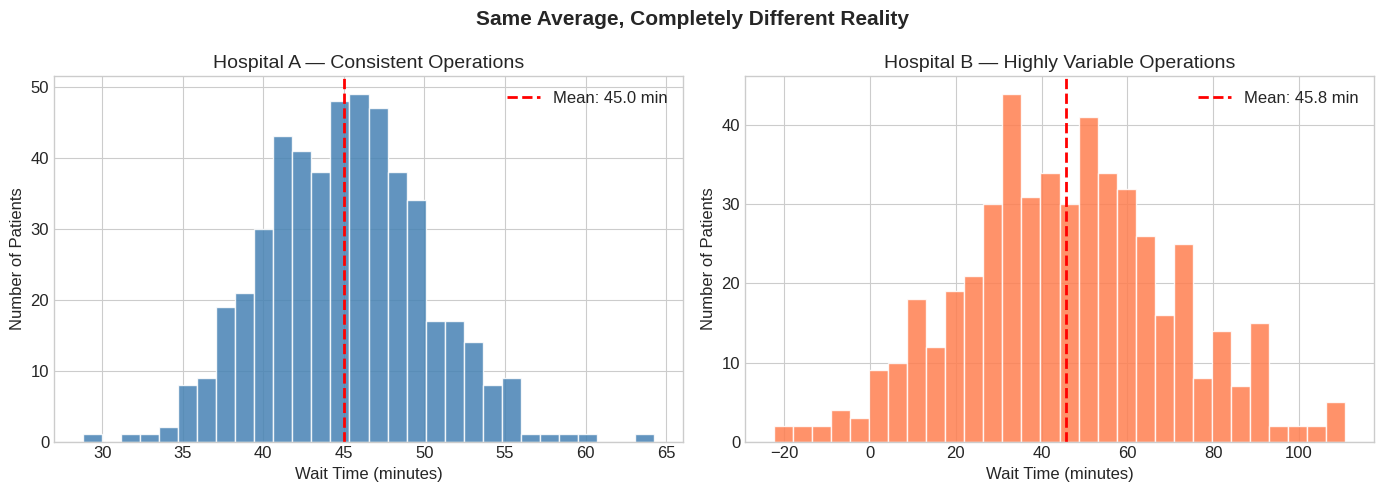

--- Summary Statistics ---
Hospital A: Mean = 45.0 min | Std Dev = 4.9 min | Max = 64 min
Hospital B: Mean = 45.8 min | Std Dev = 24.4 min | Max = 111 min

Interpretation:
Both hospitals look identical if you only read the average.
But Hospital B has patients waiting over 2 hours at the tail end.
If you are the hospital administrator, those are the patients filing complaints.
The standard deviation tells you what the average cannot.


In [2]:
# Demonstration: Why the average is never the whole story
#
# Imagine two hospitals report the same average patient wait time: 45 minutes.
# A naive analyst says they are equivalent. A statistical thinker looks deeper.

hospital_a_wait_times = np.random.normal(loc=45, scale=5, size=500)   # Tight, consistent
hospital_b_wait_times = np.random.normal(loc=45, scale=25, size=500)  # Wide, inconsistent

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hospital_a_wait_times, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(hospital_a_wait_times), color='red', linewidth=2, linestyle='--', label=f'Mean: {np.mean(hospital_a_wait_times):.1f} min')
axes[0].set_title('Hospital A — Consistent Operations')
axes[0].set_xlabel('Wait Time (minutes)')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

axes[1].hist(hospital_b_wait_times, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(hospital_b_wait_times), color='red', linewidth=2, linestyle='--', label=f'Mean: {np.mean(hospital_b_wait_times):.1f} min')
axes[1].set_title('Hospital B — Highly Variable Operations')
axes[1].set_xlabel('Wait Time (minutes)')
axes[1].set_ylabel('Number of Patients')
axes[1].legend()

plt.suptitle('Same Average, Completely Different Reality', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- Summary Statistics ---")
print(f"Hospital A: Mean = {np.mean(hospital_a_wait_times):.1f} min | Std Dev = {np.std(hospital_a_wait_times):.1f} min | Max = {np.max(hospital_a_wait_times):.0f} min")
print(f"Hospital B: Mean = {np.mean(hospital_b_wait_times):.1f} min | Std Dev = {np.std(hospital_b_wait_times):.1f} min | Max = {np.max(hospital_b_wait_times):.0f} min")
print()
print("Interpretation:")
print("Both hospitals look identical if you only read the average.")
print("But Hospital B has patients waiting over 2 hours at the tail end.")
print("If you are the hospital administrator, those are the patients filing complaints.")
print("The standard deviation tells you what the average cannot.")

---

# Section 2: Descriptive Statistics in Healthcare

## Case Study: Understanding Patient Blood Pressure Data at a Clinic

### The Business Problem

A community health clinic has been collecting blood pressure readings from 800 patients over the past year. The clinic director wants to know:

- What does the distribution of blood pressure look like across their patient population?
- Is there a meaningful difference between male and female patients?
- Which age groups are at highest risk?
- How should they allocate their limited resources for hypertension outreach?

### The Concepts We Will Use

**Measures of Center:** Mean (arithmetic average), Median (middle value), Mode (most frequent value). Each tells a different story. In healthcare, the median is often preferred because extreme values (a single outlier with 200 systolic BP) do not distort it the way they distort the mean.

**Measures of Spread:** Standard deviation tells you how far a typical value sits from the mean. Interquartile range (IQR) tells you the range containing the middle 50% of values. The IQR is robust to outliers.

**Skewness:** If data is right-skewed (long tail to the right), the mean will be higher than the median. This often happens with income, hospital costs, and wait times.

**The Five-Number Summary:** Minimum, Q1, Median, Q3, Maximum. This is the backbone of the box plot and gives a complete picture of a distribution at a glance.

In [3]:
# Generate realistic patient blood pressure dataset

np.random.seed(42)
n_patients = 800

# Patient demographics
ages = np.random.randint(20, 80, size=n_patients)
genders = np.random.choice(['Male', 'Female'], size=n_patients)

# Systolic BP varies by age and gender — this reflects real physiology
# Older patients and males tend to run slightly higher on average
systolic = []
for age, gender in zip(ages, genders):
    base = 100 + age * 0.5   # BP rises with age
    gender_adj = 3 if gender == 'Male' else 0
    noise = np.random.normal(0, 12)
    systolic.append(base + gender_adj + noise)

systolic = np.array(systolic)
# Clip to physiologically plausible range
systolic = np.clip(systolic, 85, 210)

# Diastolic is correlated with systolic but has its own variation
diastolic = systolic * 0.58 + np.random.normal(0, 7, size=n_patients)
diastolic = np.clip(diastolic, 50, 130)

# Build DataFrame
df_health = pd.DataFrame({
    'patient_id': range(1, n_patients + 1),
    'age': ages,
    'gender': genders,
    'systolic_bp': systolic.round(1),
    'diastolic_bp': diastolic.round(1),
    'age_group': pd.cut(ages, bins=[20, 35, 50, 65, 80], labels=['20-35', '35-50', '50-65', '65-80'])
})

# Classification based on standard medical guidelines
def classify_bp(row):
    s = row['systolic_bp']
    d = row['diastolic_bp']
    if s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    elif s < 140 or d < 90:
        return 'High Stage 1'
    else:
        return 'High Stage 2'

df_health['bp_category'] = df_health.apply(classify_bp, axis=1)

print("Dataset created. First 5 rows:")
print(df_health.head())
print(f"\nTotal patients: {len(df_health)}")

Dataset created. First 5 rows:
   patient_id  age  gender  systolic_bp  diastolic_bp age_group   bp_category
0           1   58    Male        144.5          91.7     50-65  High Stage 2
1           2   71  Female        127.1          68.1     65-80      Elevated
2           3   48    Male        116.1          69.4     35-50        Normal
3           4   34  Female        108.4          50.8     20-35        Normal
4           5   62  Female        131.9          72.7     50-65  High Stage 1

Total patients: 800


In [4]:
# Step 1: Compute descriptive statistics — this is always the first thing you do

print("=" * 60)
print("DESCRIPTIVE STATISTICS — SYSTOLIC BLOOD PRESSURE")
print("=" * 60)

s = df_health['systolic_bp']

print(f"  Count         : {len(s)} patients")
print(f"  Mean          : {s.mean():.1f} mmHg")
print(f"  Median        : {s.median():.1f} mmHg")
print(f"  Std Deviation : {s.std():.1f} mmHg")
print(f"  IQR           : {s.quantile(0.75) - s.quantile(0.25):.1f} mmHg")
print(f"  Skewness      : {s.skew():.3f}")
print(f"  Minimum       : {s.min():.1f} mmHg")
print(f"  Q1 (25th pct) : {s.quantile(0.25):.1f} mmHg")
print(f"  Q3 (75th pct) : {s.quantile(0.75):.1f} mmHg")
print(f"  Maximum       : {s.max():.1f} mmHg")

print()
print("--- BP Category Breakdown ---")
cat_counts = df_health['bp_category'].value_counts()
cat_pct = df_health['bp_category'].value_counts(normalize=True) * 100
for cat in ['Normal', 'Elevated', 'High Stage 1', 'High Stage 2']:
    if cat in cat_counts:
        print(f"  {cat:<16}: {cat_counts[cat]:>4} patients ({cat_pct[cat]:.1f}%)")

print()
print("--- Gender Comparison ---")
print(df_health.groupby('gender')['systolic_bp'].agg(['mean','median','std']).round(1))

DESCRIPTIVE STATISTICS — SYSTOLIC BLOOD PRESSURE
  Count         : 800 patients
  Mean          : 127.8 mmHg
  Median        : 127.5 mmHg
  Std Deviation : 15.4 mmHg
  IQR           : 21.5 mmHg
  Skewness      : 0.027
  Minimum       : 87.6 mmHg
  Q1 (25th pct) : 116.7 mmHg
  Q3 (75th pct) : 138.2 mmHg
  Maximum       : 176.1 mmHg

--- BP Category Breakdown ---
  Normal          :  244 patients (30.5%)
  Elevated        :  166 patients (20.8%)
  High Stage 1    :  332 patients (41.5%)
  High Stage 2    :   58 patients (7.2%)

--- Gender Comparison ---
         mean  median   std
gender                     
Female  126.1   126.0  14.6
Male    129.4   129.9  15.9


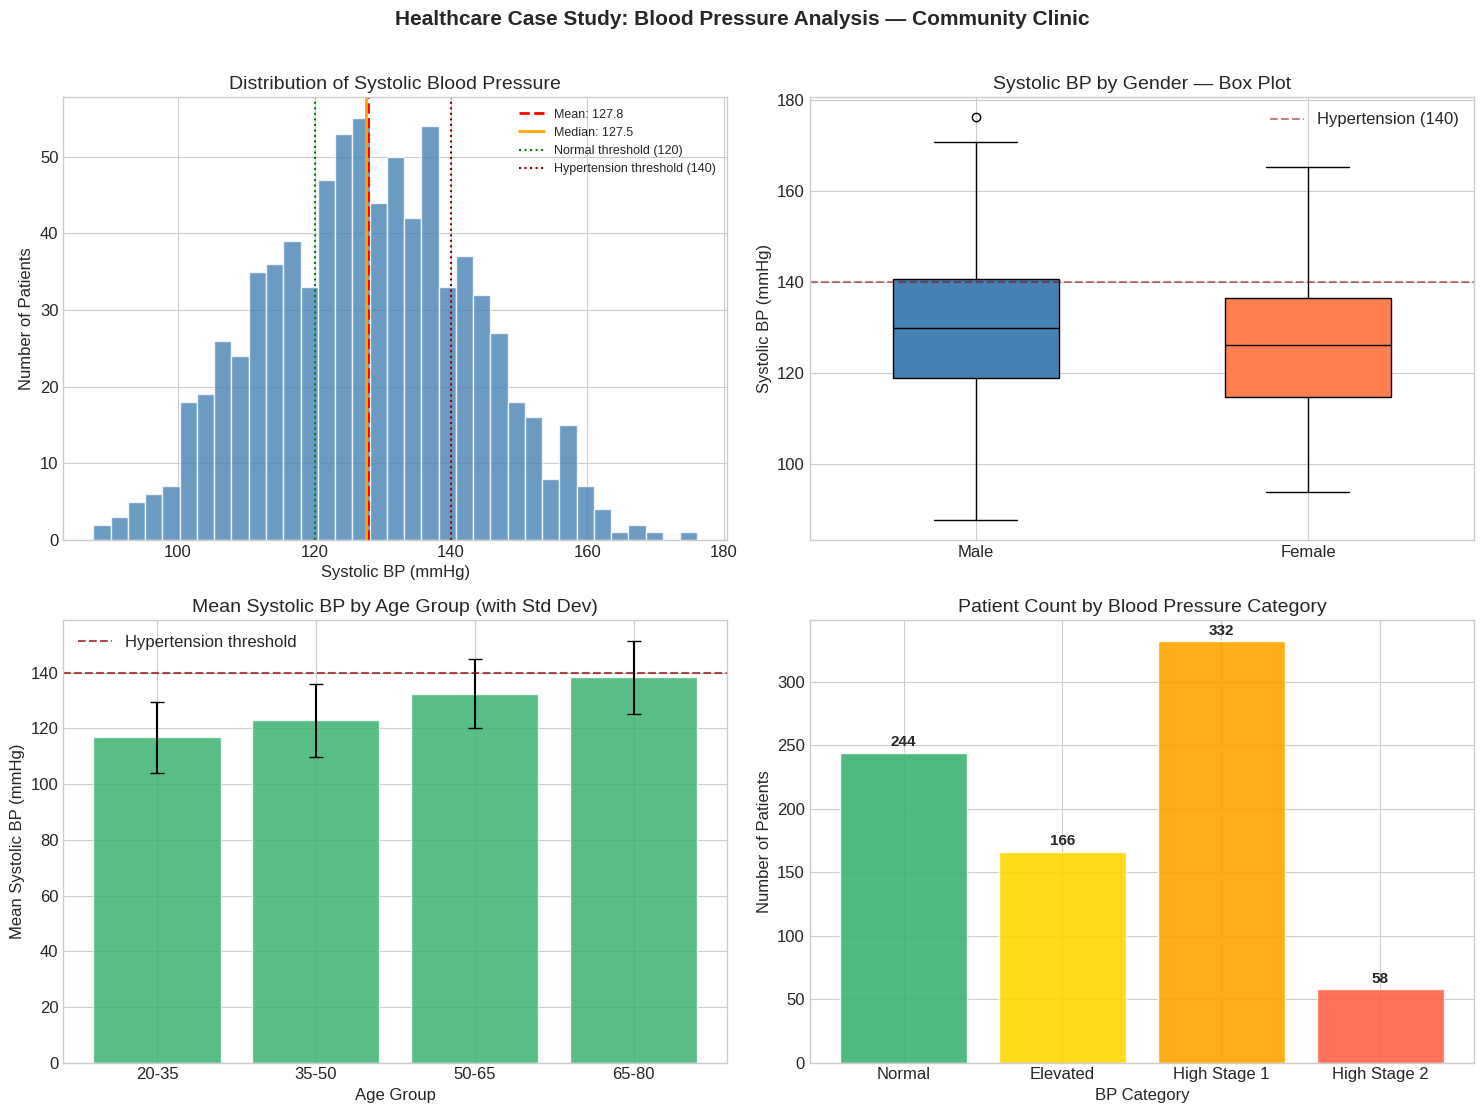

In [5]:
# Visualize the distributions

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Plot 1: Overall distribution of systolic BP ---
ax = axes[0, 0]
ax.hist(df_health['systolic_bp'], bins=35, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df_health['systolic_bp'].mean(), color='red', lw=2, linestyle='--', label=f"Mean: {df_health['systolic_bp'].mean():.1f}")
ax.axvline(df_health['systolic_bp'].median(), color='orange', lw=2, linestyle='-', label=f"Median: {df_health['systolic_bp'].median():.1f}")
ax.axvline(120, color='green', lw=1.5, linestyle=':', label='Normal threshold (120)')
ax.axvline(140, color='darkred', lw=1.5, linestyle=':', label='Hypertension threshold (140)')
ax.set_title('Distribution of Systolic Blood Pressure')
ax.set_xlabel('Systolic BP (mmHg)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

# --- Plot 2: Box plot by gender ---
ax = axes[0, 1]
colors = {'Male': 'steelblue', 'Female': 'coral'}
bp_data = [df_health[df_health['gender']=='Male']['systolic_bp'].values,
           df_health[df_health['gender']=='Female']['systolic_bp'].values]
bplot = ax.boxplot(bp_data, patch_artist=True, labels=['Male', 'Female'], widths=0.5)
bplot['boxes'][0].set_facecolor('steelblue')
bplot['boxes'][1].set_facecolor('coral')
for element in ['whiskers','caps','medians','fliers']:
    plt.setp(bplot[element], color='black')
ax.set_title('Systolic BP by Gender — Box Plot')
ax.set_ylabel('Systolic BP (mmHg)')
ax.axhline(140, color='darkred', linestyle='--', alpha=0.5, label='Hypertension (140)')
ax.legend()

# --- Plot 3: Mean BP by age group ---
ax = axes[1, 0]
age_stats = df_health.groupby('age_group', observed=True)['systolic_bp'].agg(['mean','std']).reset_index()
ax.bar(age_stats['age_group'].astype(str), age_stats['mean'],
       yerr=age_stats['std'], color='mediumseagreen', edgecolor='white',
       capsize=5, alpha=0.85)
ax.axhline(140, color='darkred', linestyle='--', alpha=0.7, label='Hypertension threshold')
ax.set_title('Mean Systolic BP by Age Group (with Std Dev)')
ax.set_xlabel('Age Group')
ax.set_ylabel('Mean Systolic BP (mmHg)')
ax.legend()

# --- Plot 4: BP category distribution ---
ax = axes[1, 1]
cat_order = ['Normal', 'Elevated', 'High Stage 1', 'High Stage 2']
cat_vals = [cat_counts.get(c, 0) for c in cat_order]
bar_colors = ['mediumseagreen', 'gold', 'orange', 'tomato']
bars = ax.bar(cat_order, cat_vals, color=bar_colors, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, cat_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Patient Count by Blood Pressure Category')
ax.set_xlabel('BP Category')
ax.set_ylabel('Number of Patients')

plt.suptitle('Healthcare Case Study: Blood Pressure Analysis — Community Clinic', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [6]:
# Interpretation and actionable recommendations

hypertensive = df_health[df_health['bp_category'].isin(['High Stage 1','High Stage 2'])]
pct_hypertensive = len(hypertensive) / len(df_health) * 100

elderly_hyp = df_health[(df_health['age_group'].astype(str).isin(['65-80'])) &
                        (df_health['bp_category'].isin(['High Stage 1','High Stage 2']))]
pct_elderly_hyp = len(elderly_hyp) / len(df_health[df_health['age_group'].astype(str).isin(['65-80'])]) * 100

print("=" * 60)
print("CLINICAL INTERPRETATION AND RESOURCE RECOMMENDATIONS")
print("=" * 60)
print()
print(f"  {pct_hypertensive:.1f}% of the clinic's patient population has Stage 1 or Stage 2 hypertension.")
print(f"  This is above the national average of approximately 47%, which suggests")
print(f"  this clinic may serve an older or higher-risk community.")
print()
print(f"  The 65-80 age group has the highest hypertension rate ({pct_elderly_hyp:.1f}%).")
print(f"  Targeted outreach programs for this group will yield the highest impact per dollar.")
print()
print(f"  Male patients show slightly higher mean systolic BP than female patients.")
print(f"  However, with standard deviations overlapping substantially, this difference")
print(f"  requires a formal hypothesis test before acting on it. (We will do this in Section 4.)")
print()
print(f"  The skewness of {df_health['systolic_bp'].skew():.3f} indicates a mild right skew.")
print(f"  This means there is a tail of patients with very high BP pulling the mean upward.")
print(f"  The median ({df_health['systolic_bp'].median():.1f}) is more representative of the typical patient.")
print()
print("Recommendation: Prioritize the 65+ hypertension cohort for monthly monitoring.")
print("Allocate education resources toward Stage 1 patients to prevent progression.")

CLINICAL INTERPRETATION AND RESOURCE RECOMMENDATIONS

  48.8% of the clinic's patient population has Stage 1 or Stage 2 hypertension.
  This is above the national average of approximately 47%, which suggests
  this clinic may serve an older or higher-risk community.

  The 65-80 age group has the highest hypertension rate (77.7%).
  Targeted outreach programs for this group will yield the highest impact per dollar.

  Male patients show slightly higher mean systolic BP than female patients.
  However, with standard deviations overlapping substantially, this difference
  requires a formal hypothesis test before acting on it. (We will do this in Section 4.)

  The skewness of 0.027 indicates a mild right skew.
  This means there is a tail of patients with very high BP pulling the mean upward.
  The median (127.5) is more representative of the typical patient.

Recommendation: Prioritize the 65+ hypertension cohort for monthly monitoring.
Allocate education resources toward Stage 1 patien

---

# Section 3: Probability Distributions in Insurance

## Case Study: Pricing a Car Insurance Policy

### The Business Problem

An insurance company needs to set premiums for car insurance policies. If they charge too little, they lose money when claims come in. If they charge too much, customers go to a competitor. The entire actuarial science field is built on one idea: model the probability distribution of claims, and price accordingly.

### The Concepts We Will Use

**Normal Distribution:** The bell curve. Arises naturally when many small, independent random effects add up. Defined by two parameters: mean (mu) and standard deviation (sigma). About 68% of data falls within 1 sigma of the mean, 95% within 2 sigma, and 99.7% within 3 sigma. This is called the empirical rule.

**Poisson Distribution:** Used to model the count of events occurring in a fixed interval of time or space, when events happen independently. Classic example: how many car accidents will this customer have per year? It has one parameter, lambda, which is both the mean and the variance.

**Exponential Distribution:** Used to model the time between events, or the size of individual claim amounts. It is right-skewed — most claims are small, but there is a long tail of catastrophic claims.

**The key actuarial formula:**

Expected payout = P(claim occurs) × E(claim amount)

The premium must cover this expected payout plus administrative costs and profit margin.

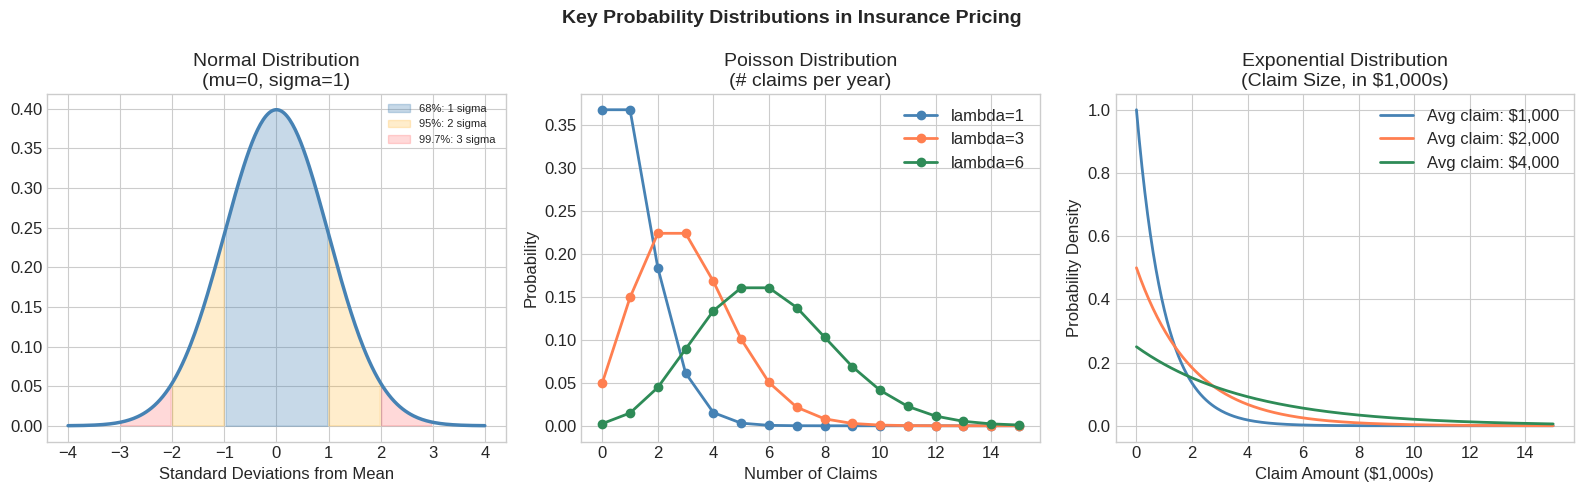

Key insight on the Exponential distribution:
Most claims cluster near zero. But the right tail is long.
That tail represents the rare but catastrophic claims that can bankrupt an insurer
if they are not priced correctly. This is why insurance companies buy reinsurance.


In [7]:
# Let us understand the three key distributions visually

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Normal Distribution
ax = axes[0]
x = np.linspace(-4, 4, 300)
ax.plot(x, norm.pdf(x), color='steelblue', lw=2.5)
ax.fill_between(x, norm.pdf(x), where=(x >= -1) & (x <= 1), alpha=0.3, color='steelblue', label='68%: 1 sigma')
ax.fill_between(x, norm.pdf(x), where=((x >= -2) & (x < -1)) | ((x > 1) & (x <= 2)), alpha=0.2, color='orange', label='95%: 2 sigma')
ax.fill_between(x, norm.pdf(x), where=((x >= -3) & (x < -2)) | ((x > 2) & (x <= 3)), alpha=0.15, color='red', label='99.7%: 3 sigma')
ax.set_title('Normal Distribution\n(mu=0, sigma=1)')
ax.set_xlabel('Standard Deviations from Mean')
ax.legend(fontsize=8)

# Poisson Distribution
ax = axes[1]
for lam, color in [(1, 'steelblue'), (3, 'coral'), (6, 'seagreen')]:
    k = np.arange(0, 16)
    ax.plot(k, poisson.pmf(k, lam), 'o-', color=color, lw=2, label=f'lambda={lam}')
ax.set_title('Poisson Distribution\n(# claims per year)')
ax.set_xlabel('Number of Claims')
ax.set_ylabel('Probability')
ax.legend()

# Exponential Distribution (claim sizes)
ax = axes[2]
x = np.linspace(0, 15, 300)
for scale, color, lbl in [(1, 'steelblue', 'Avg claim: $1,000'), (2, 'coral', 'Avg claim: $2,000'), (4, 'seagreen', 'Avg claim: $4,000')]:
    ax.plot(x, expon.pdf(x, scale=scale), lw=2, color=color, label=lbl)
ax.set_title('Exponential Distribution\n(Claim Size, in $1,000s)')
ax.set_xlabel('Claim Amount ($1,000s)')
ax.set_ylabel('Probability Density')
ax.legend()

plt.suptitle('Key Probability Distributions in Insurance Pricing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight on the Exponential distribution:")
print("Most claims cluster near zero. But the right tail is long.")
print("That tail represents the rare but catastrophic claims that can bankrupt an insurer")
print("if they are not priced correctly. This is why insurance companies buy reinsurance.")

In [8]:
# Simulate one year of claims for 10,000 policyholders

np.random.seed(42)

n_policies = 10000

# Each policyholder has a certain accident rate — modeled as Poisson
# Young drivers (age 18-25): lambda = 0.25 (25% chance of a claim per year)
# Middle-aged drivers (26-55): lambda = 0.08
# Senior drivers (56+): lambda = 0.15

segments = {
    'Young (18-25)':   {'n': 2000, 'lambda': 0.25, 'avg_claim': 4200},
    'Middle (26-55)':  {'n': 6000, 'lambda': 0.08, 'avg_claim': 3800},
    'Senior (56+)':    {'n': 2000, 'lambda': 0.15, 'avg_claim': 3500},
}

print("=" * 65)
print("INSURANCE PREMIUM CALCULATION — SIMULATION RESULTS")
print("=" * 65)
print(f"{'Segment':<20} {'Policyholders':>14} {'Claims':>8} {'Claim Rate':>12} {'Avg Claim':>10} {'Total Payout':>14} {'Break-Even Premium':>20}")
print("-" * 100)

results = []
for seg_name, params in segments.items():
    n = params['n']
    lam = params['lambda']
    avg_claim = params['avg_claim']

    # Simulate number of claims per policyholder
    claim_counts = np.random.poisson(lam, size=n)
    total_claims = claim_counts.sum()

    # Simulate claim amounts for each claim (exponentially distributed)
    claim_amounts = np.random.exponential(avg_claim, size=total_claims)
    total_payout = claim_amounts.sum()

    # Break-even premium = total payout / number of policyholders
    break_even = total_payout / n
    # Add 20% loading for overhead and profit
    recommended_premium = break_even * 1.20

    results.append({
        'segment': seg_name,
        'n': n,
        'total_claims': total_claims,
        'claim_rate': total_claims / n,
        'avg_claim_actual': claim_amounts.mean() if total_claims > 0 else 0,
        'total_payout': total_payout,
        'break_even': break_even,
        'recommended_premium': recommended_premium
    })

    print(f"{seg_name:<20} {n:>14,} {total_claims:>8,} {total_claims/n:>11.1%} {claim_amounts.mean():>9,.0f} {total_payout:>13,.0f} {recommended_premium:>19,.0f}")

print()
total_payout_all = sum(r['total_payout'] for r in results)
total_n = sum(r['n'] for r in results)
print(f"Total payout across all segments: ${total_payout_all:,.0f}")
print(f"Average break-even premium (all):  ${total_payout_all/total_n:,.0f} per year")

print()
print("Interpretation:")
print("Young drivers need to pay roughly 2-3x more than middle-aged drivers.")
print("This is not arbitrary. It directly reflects their observed claim frequency.")
print("Insurers who cannot price by segment get a phenomenon called 'adverse selection':")
print("high-risk customers buy your cheap insurance while low-risk customers go elsewhere.")

INSURANCE PREMIUM CALCULATION — SIMULATION RESULTS
Segment               Policyholders   Claims   Claim Rate  Avg Claim   Total Payout   Break-Even Premium
----------------------------------------------------------------------------------------------------
Young (18-25)                 2,000      510       25.5%     4,228     2,156,049               1,294
Middle (26-55)                6,000      467        7.8%     3,549     1,657,433                 331
Senior (56+)                  2,000      315       15.8%     3,611     1,137,532                 683

Total payout across all segments: $4,951,015
Average break-even premium (all):  $495 per year

Interpretation:
Young drivers need to pay roughly 2-3x more than middle-aged drivers.
This is not arbitrary. It directly reflects their observed claim frequency.
Insurers who cannot price by segment get a phenomenon called 'adverse selection':
high-risk customers buy your cheap insurance while low-risk customers go elsewhere.


In [9]:
# The Empirical Rule — a critical concept for any analyst
# Used to detect outliers, set control limits, and understand risk

print("THE EMPIRICAL RULE (68-95-99.7 Rule)")
print("=" * 50)
print()
print("If annual claim costs are normally distributed:")
print("  Mean = $850  |  Std Dev = $120")
print()

mu = 850
sigma = 120

print(f"  68% of policies will cost between ${mu - sigma:,.0f} and ${mu + sigma:,.0f}")
print(f"  95% of policies will cost between ${mu - 2*sigma:,.0f} and ${mu + 2*sigma:,.0f}")
print(f"  99.7% of policies will cost between ${mu - 3*sigma:,.0f} and ${mu + 3*sigma:,.0f}")
print()
print(f"  A claim exceeding ${mu + 3*sigma:,.0f} is a '3-sigma event'.")
print(f"  Probability of this: {(1 - norm.cdf(3)) * 100:.2f}%")
print(f"  In a portfolio of 10,000 policies, you would expect about {10000 * (1 - norm.cdf(3)):.0f} such cases.")
print()
print("This is how insurers set their catastrophe reserves.")
print("It is also how quality engineers set control limits on a production line.")
print("The normal distribution and the empirical rule are the most versatile tools in statistics.")

THE EMPIRICAL RULE (68-95-99.7 Rule)

If annual claim costs are normally distributed:
  Mean = $850  |  Std Dev = $120

  68% of policies will cost between $730 and $970
  95% of policies will cost between $610 and $1,090
  99.7% of policies will cost between $490 and $1,210

  A claim exceeding $1,210 is a '3-sigma event'.
  Probability of this: 0.13%
  In a portfolio of 10,000 policies, you would expect about 13 such cases.

This is how insurers set their catastrophe reserves.
It is also how quality engineers set control limits on a production line.
The normal distribution and the empirical rule are the most versatile tools in statistics.


---

# Section 4: Hypothesis Testing in Manufacturing

## Case Study: Has a Process Change Improved Product Quality?

### The Business Problem

A semiconductor fabrication plant produces microchips. Each chip is tested for defects. The current process produces chips with an average defect rate. An engineer proposes a change to the chemical etching process, claiming it will reduce defects. The factory tests the new process on a sample of 150 chips while continuing the old process on another 150 chips.

The question: Is the difference between the two samples real, or could it be explained by random chance?

### The Concepts We Will Use

**The Null Hypothesis (H0):** The assumption that nothing has changed. In our case: the new process does not change defect rates. We start by assuming the null is true, and we only reject it if the data gives us very strong evidence against it.

**The Alternative Hypothesis (H1):** What we are trying to prove. The new process reduces defects.

**The p-value:** The probability of observing a result as extreme as ours if the null hypothesis were actually true. A small p-value means our data is unlikely under the null — evidence against it. The conventional threshold is p < 0.05.

**Type I Error (False Positive):** We reject the null when it was actually true. We say the new process is better when it is not. We might roll out an expensive change that does nothing.

**Type II Error (False Negative):** We fail to reject the null when it was actually false. We miss a genuinely better process.

**Statistical Power:** The probability of detecting a real effect when one exists. Power depends on sample size, effect size, and significance level.

**The t-test:** Used to compare means between two groups when the population standard deviation is unknown (which is almost always). The test statistic follows a t-distribution, which accounts for the extra uncertainty from estimating the standard deviation.

In [10]:
# Simulate chip defect data for both processes

np.random.seed(42)

n_samples = 150

# Old process: mean defect score of 5.2, std dev of 1.8
old_process = np.random.normal(loc=5.2, scale=1.8, size=n_samples)
old_process = np.clip(old_process, 0, 12)  # Physical limits

# New process: engineer claims mean defect score of 4.6 — a genuine improvement
new_process = np.random.normal(loc=4.6, scale=1.9, size=n_samples)
new_process = np.clip(new_process, 0, 12)

print("STEP 1: STATE THE HYPOTHESES")
print("-" * 45)
print("  H0: Mean defects (new) >= Mean defects (old)  [no improvement]")
print("  H1: Mean defects (new) <  Mean defects (old)  [new process is better]")
print("  Significance level alpha = 0.05")
print("  This is a one-tailed test (we only care if new is LOWER)")
print()

print("STEP 2: EXAMINE THE DATA")
print("-" * 45)
print(f"  Old Process: n={n_samples}, mean={old_process.mean():.3f}, std={old_process.std():.3f}")
print(f"  New Process: n={n_samples}, mean={new_process.mean():.3f}, std={new_process.std():.3f}")
print(f"  Observed difference: {old_process.mean() - new_process.mean():.3f} fewer defects")
print()

print("STEP 3: CHECK NORMALITY ASSUMPTION (Shapiro-Wilk Test)")
print("-" * 45)
stat_old, p_old = shapiro(old_process)
stat_new, p_new = shapiro(new_process)
print(f"  Old Process: W={stat_old:.4f}, p-value={p_old:.4f} — {'Normal' if p_old > 0.05 else 'Non-normal'}")
print(f"  New Process: W={stat_new:.4f}, p-value={p_new:.4f} — {'Normal' if p_new > 0.05 else 'Non-normal'}")
print()

print("STEP 4: RUN THE INDEPENDENT SAMPLES t-TEST")
print("-" * 45)
t_stat, p_two_tailed = ttest_ind(old_process, new_process)
p_one_tailed = p_two_tailed / 2  # One-tailed since we expect new < old
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value (two-tailed): {p_two_tailed:.4f}")
print(f"  p-value (one-tailed): {p_one_tailed:.4f}")
print()

print("STEP 5: DECISION")
print("-" * 45)
alpha = 0.05
if p_one_tailed < alpha:
    print(f"  p={p_one_tailed:.4f} < alpha={alpha}")
    print("  REJECT the null hypothesis.")
    print("  Conclusion: The new process produces statistically significantly fewer defects.")
    print("  The factory should consider rolling out the new process.")
else:
    print(f"  p={p_one_tailed:.4f} >= alpha={alpha}")
    print("  FAIL TO REJECT the null hypothesis.")
    print("  The observed difference could be due to chance.")

STEP 1: STATE THE HYPOTHESES
---------------------------------------------
  H0: Mean defects (new) >= Mean defects (old)  [no improvement]
  H1: Mean defects (new) <  Mean defects (old)  [new process is better]
  Significance level alpha = 0.05
  This is a one-tailed test (we only care if new is LOWER)

STEP 2: EXAMINE THE DATA
---------------------------------------------
  Old Process: n=150, mean=5.052, std=1.691
  New Process: n=150, mean=4.746, std=1.905
  Observed difference: 0.306 fewer defects

STEP 3: CHECK NORMALITY ASSUMPTION (Shapiro-Wilk Test)
---------------------------------------------
  Old Process: W=0.9958, p-value=0.9480 — Normal
  New Process: W=0.9853, p-value=0.1111 — Normal

STEP 4: RUN THE INDEPENDENT SAMPLES t-TEST
---------------------------------------------
  t-statistic : 1.4670
  p-value (two-tailed): 0.1434
  p-value (one-tailed): 0.0717

STEP 5: DECISION
---------------------------------------------
  p=0.0717 >= alpha=0.05
  FAIL TO REJECT the null hy

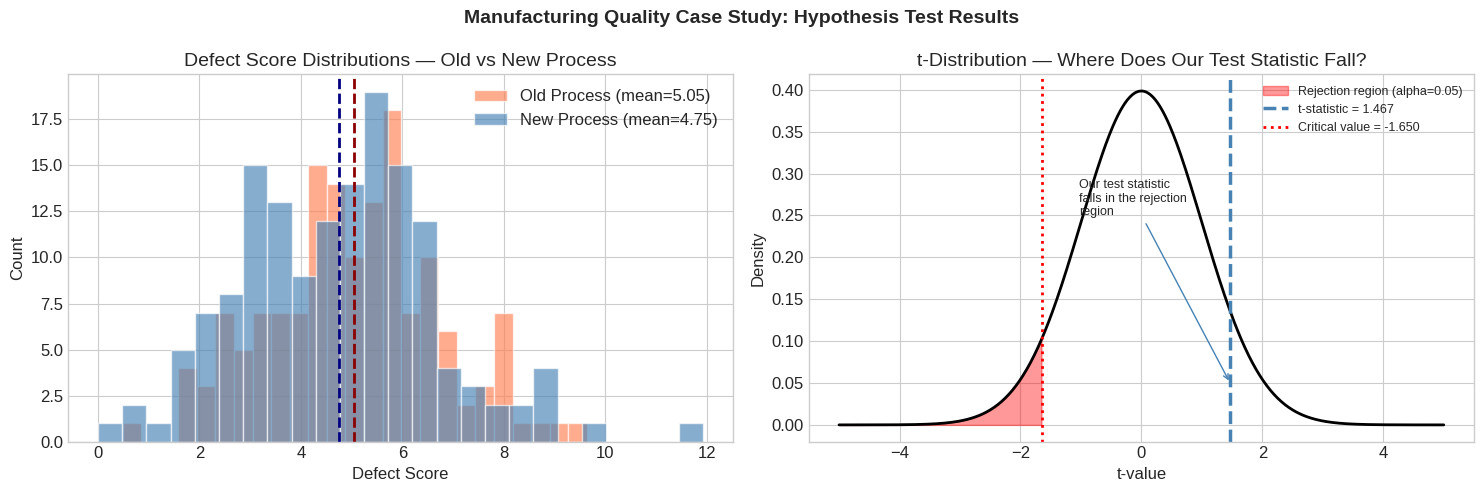

In [11]:
# Visualize the hypothesis test

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: Distribution of defect scores ---
ax = axes[0]
ax.hist(old_process, bins=25, color='coral', alpha=0.65, edgecolor='white', label=f'Old Process (mean={old_process.mean():.2f})')
ax.hist(new_process, bins=25, color='steelblue', alpha=0.65, edgecolor='white', label=f'New Process (mean={new_process.mean():.2f})')
ax.axvline(old_process.mean(), color='darkred', lw=2, linestyle='--')
ax.axvline(new_process.mean(), color='navy', lw=2, linestyle='--')
ax.set_title('Defect Score Distributions — Old vs New Process')
ax.set_xlabel('Defect Score')
ax.set_ylabel('Count')
ax.legend()

# --- Right: t-distribution and critical region ---
ax = axes[1]
df = 2 * n_samples - 2  # degrees of freedom
x = np.linspace(-5, 5, 500)
t_dist = t.pdf(x, df=df)
ax.plot(x, t_dist, color='black', lw=2)

# Critical value for alpha=0.05, one-tailed
crit_val = t.ppf(0.05, df=df)
ax.fill_between(x, t_dist, where=(x <= crit_val), color='red', alpha=0.4, label=f'Rejection region (alpha=0.05)')
ax.axvline(t_stat, color='steelblue', lw=2.5, linestyle='--', label=f't-statistic = {t_stat:.3f}')
ax.axvline(crit_val, color='red', lw=2, linestyle=':', label=f'Critical value = {crit_val:.3f}')
ax.set_title('t-Distribution — Where Does Our Test Statistic Fall?')
ax.set_xlabel('t-value')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.annotate('Our test statistic\nfalls in the rejection\nregion', xy=(t_stat, 0.05),
            xytext=(t_stat-2.5, 0.25), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='steelblue'))

plt.suptitle('Manufacturing Quality Case Study: Hypothesis Test Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Effect size: statistical significance vs practical significance
# A result can be statistically significant but practically meaningless
# Cohen's d measures the magnitude of the effect

pooled_std = np.sqrt((old_process.std()**2 + new_process.std()**2) / 2)
cohens_d = (old_process.mean() - new_process.mean()) / pooled_std

# Confidence interval for the difference in means
diff = old_process.mean() - new_process.mean()
se_diff = np.sqrt(old_process.var()/n_samples + new_process.var()/n_samples)
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print("EFFECT SIZE AND CONFIDENCE INTERVAL")
print("=" * 50)
print()
print(f"  Cohen's d = {cohens_d:.3f}")
print()
print("  Interpretation of Cohen's d:")
print("    d < 0.2   = Negligible effect")
print("    d = 0.2   = Small effect")
print("    d = 0.5   = Medium effect")
print("    d >= 0.8  = Large effect")
print()
if cohens_d < 0.2:
    verdict = "Negligible — statistically significant but practically unimportant."
elif cohens_d < 0.5:
    verdict = "Small — worth investigating further with cost-benefit analysis."
elif cohens_d < 0.8:
    verdict = "Medium — a meaningful engineering improvement."
else:
    verdict = "Large — a major breakthrough worth implementing immediately."
print(f"  Our effect size: {verdict}")
print()
print(f"  95% Confidence Interval for the difference in means:")
print(f"  ({ci_lower:.3f}, {ci_upper:.3f})")
print()
print("  This means: we are 95% confident that the new process reduces")
print(f"  defects by between {ci_lower:.2f} and {ci_upper:.2f} units on average.")
print()
print("  Critical lesson: Always pair a p-value with an effect size and confidence interval.")
print("  A p-value only tells you 'is this real?'. It does not tell you 'does this matter?'")

EFFECT SIZE AND CONFIDENCE INTERVAL

  Cohen's d = 0.170

  Interpretation of Cohen's d:
    d < 0.2   = Negligible effect
    d = 0.2   = Small effect
    d = 0.5   = Medium effect
    d >= 0.8  = Large effect

  Our effect size: Negligible — statistically significant but practically unimportant.

  95% Confidence Interval for the difference in means:
  (-0.102, 0.714)

  This means: we are 95% confident that the new process reduces
  defects by between -0.10 and 0.71 units on average.

  Critical lesson: Always pair a p-value with an effect size and confidence interval.
  A p-value only tells you 'is this real?'. It does not tell you 'does this matter?'


---

# Section 5: Regression Analysis in Real Estate

## Case Study: Building a Property Valuation Model

### The Business Problem

A real estate investment firm wants to build a model to estimate the fair market value of residential properties. They have data on 500 recent sales including property size, number of bedrooms, age of the building, distance from the city center, and neighborhood quality score. They want to:

- Understand which features drive property value most
- Build a model to estimate the value of properties not yet on the market
- Identify undervalued properties (where the actual sale price is significantly below the model's estimate)

### The Concepts We Will Use

**Simple Linear Regression:** Models the relationship between one predictor and one outcome as a straight line: Y = beta_0 + beta_1 * X + error. Beta_0 is the intercept (value when X=0), beta_1 is the slope (change in Y per unit change in X).

**Multiple Linear Regression:** Extends simple regression to multiple predictors: Y = beta_0 + beta_1*X1 + beta_2*X2 + ... + error. Each coefficient represents the effect of that variable while holding all others constant.

**R-squared:** The proportion of variance in the outcome explained by the model. R2=0.80 means the model explains 80% of the variation in house prices. The remaining 20% is unexplained — noise, or variables we do not have.

**Residuals:** The difference between the actual value and the model's prediction. Residuals should be randomly scattered around zero. Patterns in residuals indicate the model is missing something.

In [13]:
# Generate realistic real estate dataset

np.random.seed(42)
n_properties = 500

# Features
size_sqft = np.random.normal(1800, 400, n_properties).clip(600, 4000)  # Square footage
bedrooms  = np.random.choice([1, 2, 3, 4, 5], p=[0.05, 0.20, 0.45, 0.25, 0.05], size=n_properties)
age_years = np.random.exponential(15, n_properties).clip(0, 80)        # Most homes are newer
dist_city = np.random.exponential(8, n_properties).clip(0.5, 40)       # Miles from city center
neighborhood_score = np.random.uniform(1, 10, n_properties)            # Quality of neighborhood (1-10)

# True price generation — this is the 'ground truth' model we are trying to recover
base_price = 80000
price = (
    base_price
    + size_sqft * 120            # $120 per sqft
    + bedrooms * 8000            # $8k per bedroom
    - age_years * 1500           # Older = cheaper
    - dist_city * 4000           # Farther from city = cheaper
    + neighborhood_score * 12000 # Better neighborhood = more expensive
    + np.random.normal(0, 25000, n_properties)  # Idiosyncratic noise
)

price = price.clip(50000, 1200000)

df_re = pd.DataFrame({
    'price':              price.round(-3),
    'size_sqft':          size_sqft.round(0),
    'bedrooms':           bedrooms,
    'age_years':          age_years.round(1),
    'dist_city_miles':    dist_city.round(2),
    'neighborhood_score': neighborhood_score.round(1)
})

print("Real Estate Dataset — Summary Statistics")
print(df_re.describe().round(0).to_string())

Real Estate Dataset — Summary Statistics
          price  size_sqft  bedrooms  age_years  dist_city_miles  neighborhood_score
count     500.0      500.0     500.0      500.0            500.0               500.0
mean   332214.0     1803.0       3.0       15.0              8.0                 5.0
std     71651.0      392.0       1.0       15.0              8.0                 3.0
min    132000.0      600.0       1.0        0.0              0.0                 1.0
25%    284000.0     1520.0       2.0        4.0              2.0                 4.0
50%    331000.0     1805.0       3.0       11.0              6.0                 5.0
75%    380000.0     2055.0       4.0       20.0             11.0                 8.0
max    579000.0     3341.0       5.0       80.0             40.0                10.0


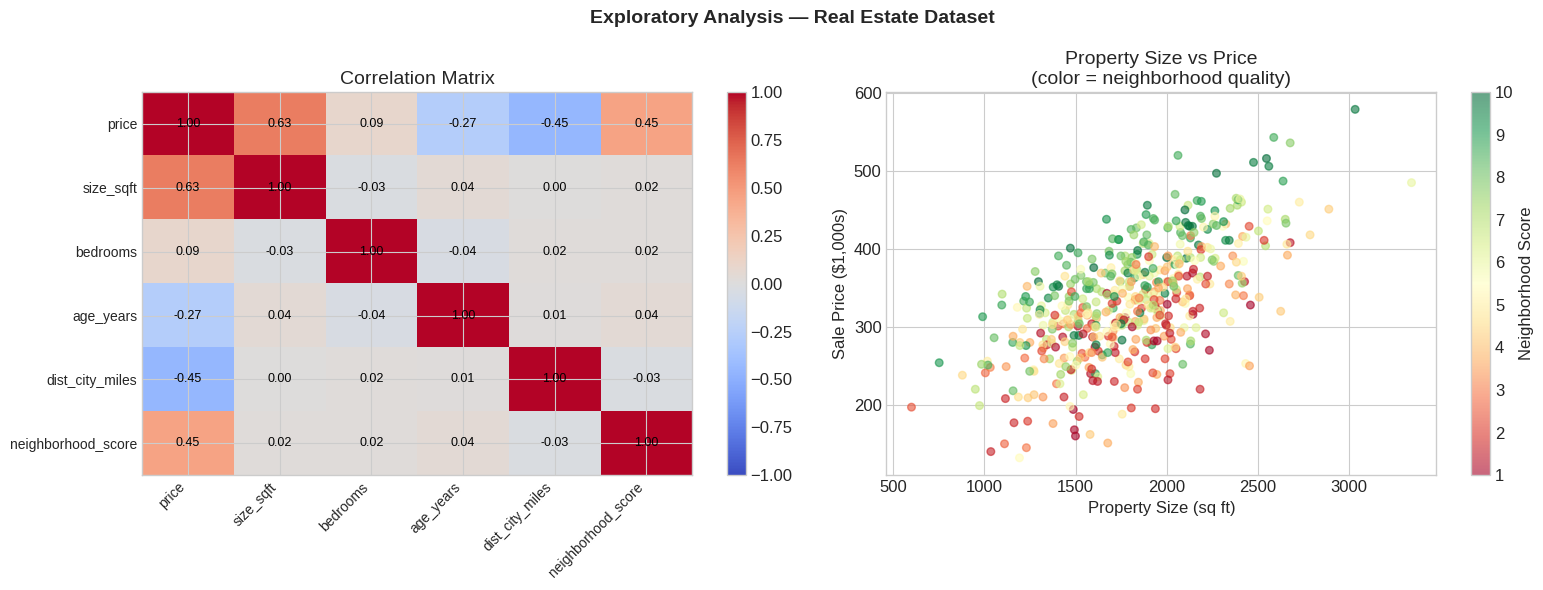

Top correlations with price:
size_sqft             0.626
neighborhood_score    0.452
bedrooms              0.091
age_years            -0.266
dist_city_miles      -0.454


In [14]:
# Exploratory step: correlation matrix — understand relationships before modeling

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
ax = axes[0]
corr = df_re.corr().round(2)
mask = np.zeros_like(corr)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr.columns, fontsize=10)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='black')
plt.colorbar(im, ax=ax)
ax.set_title('Correlation Matrix')

# Scatter: size vs price (most important predictor)
ax = axes[1]
scatter = ax.scatter(df_re['size_sqft'], df_re['price'] / 1000,
                     c=df_re['neighborhood_score'], cmap='RdYlGn',
                     alpha=0.6, s=30)
plt.colorbar(scatter, ax=ax, label='Neighborhood Score')
ax.set_xlabel('Property Size (sq ft)')
ax.set_ylabel('Sale Price ($1,000s)')
ax.set_title('Property Size vs Price\n(color = neighborhood quality)')

plt.suptitle('Exploratory Analysis — Real Estate Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top correlations with price:")
print(df_re.corr()['price'].drop('price').sort_values(ascending=False).round(3).to_string())

In [15]:
# Build the regression model

features = ['size_sqft', 'bedrooms', 'age_years', 'dist_city_miles', 'neighborhood_score']
X = df_re[features]
y = df_re['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test.values - y_pred

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 60)
print("REGRESSION MODEL RESULTS")
print("=" * 60)
print()
print(f"  Intercept: ${model.intercept_:,.0f}")
print()
print("  Coefficients (how much each feature changes the price):")
for feat, coef in zip(features, model.coef_):
    direction = 'increases' if coef > 0 else 'decreases'
    print(f"    {feat:<22}: ${coef:>9,.0f}  (1 unit increase {direction} price by this amount)")

print()
print(f"  Model Performance:")
print(f"    R-squared : {r2:.4f} — The model explains {r2*100:.1f}% of price variation")
print(f"    RMSE      : ${rmse:,.0f} — Average prediction error")
print()
print("Interpretation:")
print(f"  Each additional square foot adds approximately ${model.coef_[0]:,.0f} to the price.")
print(f"  Each year of age reduces the price by approximately ${abs(model.coef_[2]):,.0f}.")
print(f"  A 1-point improvement in neighborhood score adds approximately ${model.coef_[4]:,.0f}.")
print(f"  These coefficients allow us to decompose what is driving any specific property's value.")

REGRESSION MODEL RESULTS

  Intercept: $85,665

  Coefficients (how much each feature changes the price):
    size_sqft             : $      116  (1 unit increase increases price by this amount)
    bedrooms              : $    8,306  (1 unit increase increases price by this amount)
    age_years             : $   -1,451  (1 unit increase decreases price by this amount)
    dist_city_miles       : $   -4,095  (1 unit increase decreases price by this amount)
    neighborhood_score    : $   12,091  (1 unit increase increases price by this amount)

  Model Performance:
    R-squared : 0.8724 — The model explains 87.2% of price variation
    RMSE      : $22,284 — Average prediction error

Interpretation:
  Each additional square foot adds approximately $116 to the price.
  Each year of age reduces the price by approximately $1,451.
  A 1-point improvement in neighborhood score adds approximately $12,091.
  These coefficients allow us to decompose what is driving any specific property's val

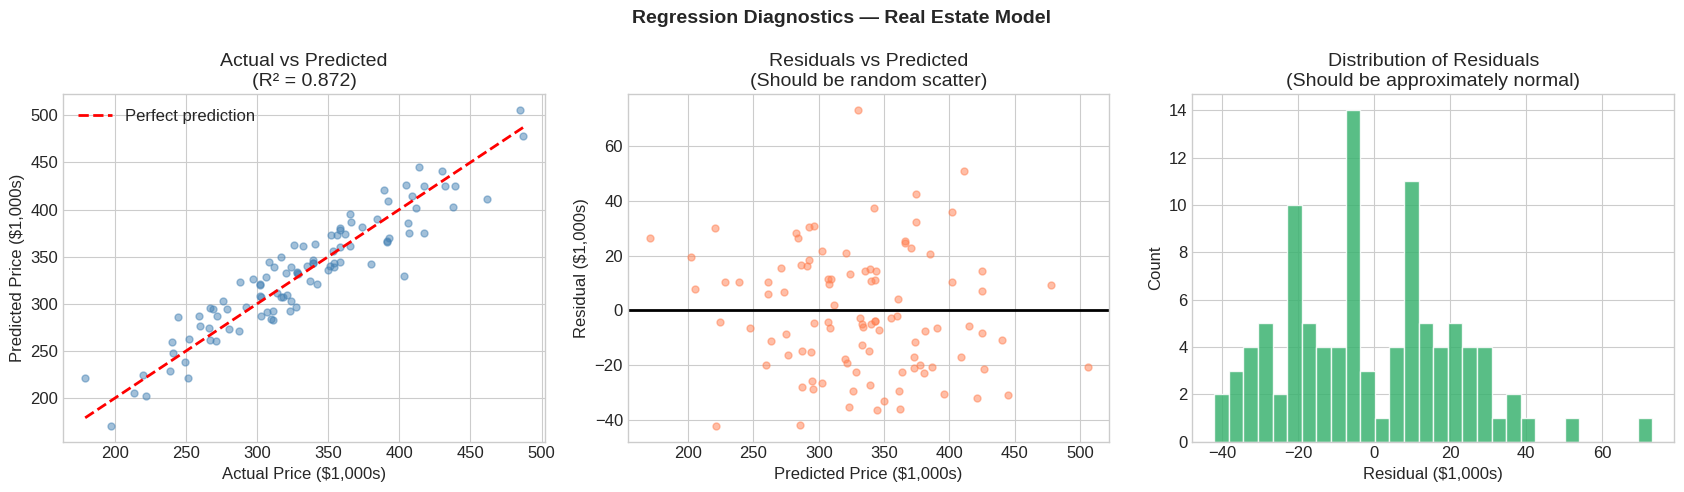

TOP 5 UNDERVALUED PROPERTIES (Actual Price Significantly Below Model Estimate):
    Actual Price Model Estimate Undervalued By
347     $179,000       $221,143        $42,143
84      $244,000       $285,796        $41,796
155     $308,000       $344,460        $36,460
381     $326,000       $362,105        $36,105
101     $288,000       $323,224        $35,224

These are potential investment opportunities — properties where the market
price does not reflect the full value implied by the property's features.


In [16]:
# Residual analysis — this is how you know if your model is trustworthy

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_test/1000, y_pred/1000, alpha=0.5, s=25, color='steelblue')
perfect_line = np.linspace(y_test.min()/1000, y_test.max()/1000, 100)
ax.plot(perfect_line, perfect_line, 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Price ($1,000s)')
ax.set_ylabel('Predicted Price ($1,000s)')
ax.set_title(f'Actual vs Predicted\n(R² = {r2:.3f})')
ax.legend()

# Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred/1000, residuals/1000, alpha=0.5, s=25, color='coral')
ax.axhline(0, color='black', lw=2)
ax.set_xlabel('Predicted Price ($1,000s)')
ax.set_ylabel('Residual ($1,000s)')
ax.set_title('Residuals vs Predicted\n(Should be random scatter)')

# Residual distribution
ax = axes[2]
ax.hist(residuals/1000, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_xlabel('Residual ($1,000s)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals\n(Should be approximately normal)')

plt.suptitle('Regression Diagnostics — Real Estate Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find the most undervalued properties
df_test = X_test.copy()
df_test['actual_price']    = y_test.values
df_test['predicted_price'] = y_pred
df_test['residual']        = residuals
df_test['undervalued_by']  = -residuals  # Negative residual = actual < predicted = undervalued

print("TOP 5 UNDERVALUED PROPERTIES (Actual Price Significantly Below Model Estimate):")
undervalued = df_test.nlargest(5, 'undervalued_by')[['actual_price','predicted_price','undervalued_by']]
undervalued.columns = ['Actual Price', 'Model Estimate', 'Undervalued By']
undervalued = undervalued.applymap(lambda x: f"${x:,.0f}")
print(undervalued.to_string())
print()
print("These are potential investment opportunities — properties where the market")
print("price does not reflect the full value implied by the property's features.")


---

# Section 6: A/B Testing in Technology

## Case Study: Should We Change the Checkout Button?

### The Business Problem

A software company runs an e-commerce platform. Their product team wants to test a new checkout button design (Version B — orange, larger text) against the existing design (Version A — green, standard text). They hypothesize the new design will increase checkout completion rates.

Over one week, 20,000 users are randomly assigned to see either version A or version B. Each user either completes checkout (1) or abandons (0).

The stakes are high. If Version B genuinely increases conversion by 1%, that could translate to hundreds of thousands in additional annual revenue. But if we are wrong — if that 1% difference was just noise — we have wasted engineering resources and possibly confused users.

### The Concepts We Will Use

**Conversion Rate:** The proportion of users who complete the desired action. If 500 out of 10,000 users checked out, the conversion rate is 5%.

**Chi-squared test / Proportion z-test:** Used to compare proportions (conversion rates) rather than means. Our outcome is binary (converted or not), so we need a different test than the t-test.

**Sample Size Calculation:** Before running the test, you must calculate how many users you need to detect the expected effect with adequate statistical power. Running for too short leaves you underpowered; running for too long risks peeking at data repeatedly (which inflates false positive rates).

**Practical vs Statistical Significance:** An A/B test with 10 million users can detect differences of 0.001% as statistically significant. But is a 0.001% change worth deploying? You must also check that the measured lift is large enough to justify the engineering effort.

In [17]:
# Step 1: Calculate required sample size BEFORE running the experiment
# This is what separates rigorous A/B testing from just looking at numbers

from scipy.stats import norm as norm_dist

def calculate_sample_size(p_baseline, mde, alpha=0.05, power=0.80):
    """
    p_baseline: current conversion rate
    mde: minimum detectable effect (absolute change you care about)
    alpha: significance level (Type I error rate)
    power: 1 - beta (probability of detecting a real effect)
    """
    p_treatment = p_baseline + mde
    p_avg = (p_baseline + p_treatment) / 2

    z_alpha = norm_dist.ppf(1 - alpha / 2)  # Two-tailed
    z_beta  = norm_dist.ppf(power)

    n = (z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) +
         z_beta  * np.sqrt(p_baseline * (1 - p_baseline) + p_treatment * (1 - p_treatment)))**2 / mde**2

    return int(np.ceil(n))

baseline_conversion = 0.05   # Current rate: 5%
min_detectable_effect = 0.01  # We want to detect at least a 1% absolute lift (5% -> 6%)

n_required = calculate_sample_size(baseline_conversion, min_detectable_effect)

print("A/B TEST — PRE-EXPERIMENT PLANNING")
print("=" * 55)
print(f"  Baseline conversion rate: {baseline_conversion:.0%}")
print(f"  Minimum detectable effect: +{min_detectable_effect:.0%} (absolute)")
print(f"  Significance level (alpha): 0.05")
print(f"  Statistical power: 80%")
print()
print(f"  Required sample size per variant: {n_required:,} users")
print(f"  Total users needed: {n_required*2:,} users")
print()
print("  If your platform gets 5,000 visitors/day, you need at minimum")
print(f"  {n_required*2 / 5000:.1f} days to run this test with adequate power.")
print()
print("  WARNING: Do not peek at results early and stop based on what you see.")
print("  'Peeking' inflates the false positive rate dramatically.")
print("  Commit to your sample size before the test begins.")

A/B TEST — PRE-EXPERIMENT PLANNING
  Baseline conversion rate: 5%
  Minimum detectable effect: +1% (absolute)
  Significance level (alpha): 0.05
  Statistical power: 80%

  Required sample size per variant: 8,158 users
  Total users needed: 16,316 users

  If your platform gets 5,000 visitors/day, you need at minimum
  3.3 days to run this test with adequate power.

  'Peeking' inflates the false positive rate dramatically.
  Commit to your sample size before the test begins.


In [18]:
# Simulate the A/B test with 10,000 users per variant

np.random.seed(42)

n_per_variant = 10000

# Version A (control): 5.0% conversion
# Version B (treatment): 6.2% conversion — a genuine improvement
version_a = np.random.binomial(1, 0.050, size=n_per_variant)
version_b = np.random.binomial(1, 0.062, size=n_per_variant)

# Summary
conv_a = version_a.mean()
conv_b = version_b.mean()
lift   = (conv_b - conv_a) / conv_a * 100

print("A/B TEST RESULTS")
print("=" * 55)
print(f"  Version A (Control): {version_a.sum():,} conversions / {n_per_variant:,} users = {conv_a:.2%}")
print(f"  Version B (Test):    {version_b.sum():,} conversions / {n_per_variant:,} users = {conv_b:.2%}")
print(f"  Observed Lift: +{conv_b - conv_a:.2%} absolute  (+{lift:.1f}% relative)")
print()

# Two-proportion z-test
from statsmodels.stats.proportion import proportions_ztest

count  = np.array([version_b.sum(), version_a.sum()])
nobs   = np.array([n_per_variant, n_per_variant])
z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

# Confidence interval for the difference
diff = conv_b - conv_a
se   = np.sqrt(conv_a*(1-conv_a)/n_per_variant + conv_b*(1-conv_b)/n_per_variant)
ci_l = diff - 1.96 * se
ci_u = diff + 1.96 * se

print(f"  Statistical Test: Two-proportion z-test (one-tailed)")
print(f"  z-statistic: {z_stat:.4f}")
print(f"  p-value:     {p_val:.4f}")
print(f"  95% CI for difference: ({ci_l:.4f}, {ci_u:.4f})")
print()

if p_val < 0.05:
    print("  DECISION: REJECT the null hypothesis.")
    print("  Version B is statistically significantly better.")
    print("  Recommend shipping Version B to all users.")
else:
    print("  DECISION: FAIL TO REJECT the null hypothesis.")
    print("  Insufficient evidence to conclude B outperforms A.")

print()
# Business impact estimate
monthly_visitors = 300000
avg_order_value  = 85
additional_revenue = monthly_visitors * (conv_b - conv_a) * avg_order_value
print(f"  BUSINESS IMPACT ESTIMATE:")
print(f"  Monthly visitors: {monthly_visitors:,}")
print(f"  Average order value: ${avg_order_value}")
print(f"  Additional monthly revenue from lift: ${additional_revenue:,.0f}")
print(f"  Projected annual impact: ${additional_revenue*12:,.0f}")

A/B TEST RESULTS
  Version A (Control): 474 conversions / 10,000 users = 4.74%
  Version B (Test):    634 conversions / 10,000 users = 6.34%
  Observed Lift: +1.60% absolute  (+33.8% relative)

  Statistical Test: Two-proportion z-test (one-tailed)
  z-statistic: 4.9457
  p-value:     0.0000
  95% CI for difference: (0.0097, 0.0223)

  DECISION: REJECT the null hypothesis.
  Version B is statistically significantly better.
  Recommend shipping Version B to all users.

  BUSINESS IMPACT ESTIMATE:
  Monthly visitors: 300,000
  Average order value: $85
  Additional monthly revenue from lift: $408,000
  Projected annual impact: $4,896,000


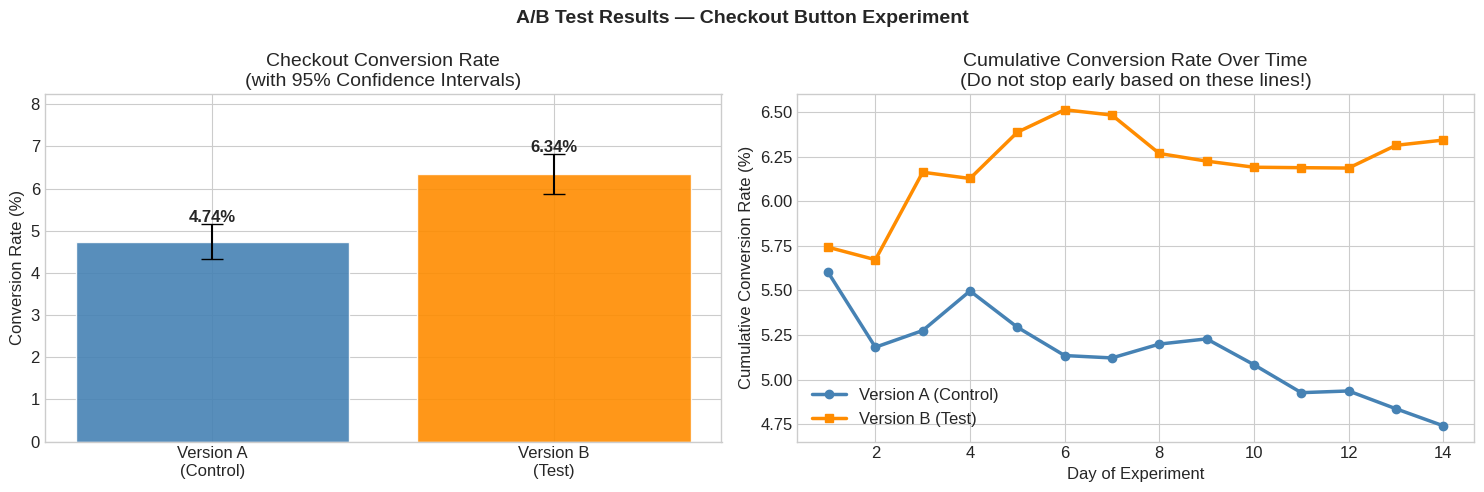

In [19]:
# Visualize the A/B test results

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Conversion rate comparison ---
ax = axes[0]
versions = ['Version A\n(Control)', 'Version B\n(Test)']
rates = [conv_a * 100, conv_b * 100]
ci_errors = [1.96 * np.sqrt(conv_a*(1-conv_a)/n_per_variant) * 100,
             1.96 * np.sqrt(conv_b*(1-conv_b)/n_per_variant) * 100]
bars = ax.bar(versions, rates, color=['steelblue', 'darkorange'],
              yerr=ci_errors, capsize=8, edgecolor='white', alpha=0.9)
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Checkout Conversion Rate\n(with 95% Confidence Intervals)')
ax.set_ylim(0, max(rates) * 1.3)
for bar, rate, err in zip(bars, rates, ci_errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.05,
            f'{rate:.2f}%', ha='center', fontsize=12, fontweight='bold')

# --- Cumulative conversion over time (simulated) ---
ax = axes[1]
days = np.arange(1, 15)
daily_n = n_per_variant // 14
cum_conv_a = []
cum_conv_b = []
for d in days:
    cum_conv_a.append(version_a[:d*daily_n].mean() * 100)
    cum_conv_b.append(version_b[:d*daily_n].mean() * 100)

ax.plot(days, cum_conv_a, 'o-', color='steelblue', lw=2.5, label='Version A (Control)')
ax.plot(days, cum_conv_b, 's-', color='darkorange', lw=2.5, label='Version B (Test)')
ax.set_xlabel('Day of Experiment')
ax.set_ylabel('Cumulative Conversion Rate (%)')
ax.set_title('Cumulative Conversion Rate Over Time\n(Do not stop early based on these lines!)')
ax.legend()

plt.suptitle('A/B Test Results — Checkout Button Experiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Section 7: Time Series Analysis in Retail

## Case Study: Forecasting Weekly Sales for Inventory Planning

### The Business Problem

A national grocery chain needs to forecast weekly sales for each product category to optimize inventory levels. If they over-order, they waste money on perishables and storage. If they under-order, they have empty shelves and lose sales. The forecasting team needs to understand the patterns in historical sales data before building a model.

### The Concepts We Will Use

**Trend:** The long-run direction of the data. Sales could be slowly growing, declining, or flat over months and years.

**Seasonality:** Predictable, repeating cycles. Grocery sales are higher on weekends, higher in November-December, and drop in January. Seasonality has a known frequency.

**Noise (Residual):** The random, unexplained variation left after removing trend and seasonality. Truly random noise cannot be predicted and should not be modeled.

**Decomposition:** The process of separating a time series into its components (Trend + Seasonal + Residual). This helps us understand what is driving the data.

**Moving Average:** A simple smoothing technique that averages observations over a rolling window. It eliminates short-term noise to reveal the underlying trend.

**Autocorrelation:** The correlation of a time series with its own past values. High autocorrelation at lag 7 means 'what happened last week predicts what happens this week.' This is the foundation of ARIMA models.

In [21]:
# Generate 2 years of weekly grocery sales data with realistic structure

np.random.seed(42)

weeks = 104  # 2 years
t = np.arange(weeks)

# Components
trend     = 50000 + t * 150                           # Slow upward trend ($150/week growth)
seasonal  = 8000  * np.sin(2 * np.pi * t / 52)        # Annual cycle, peak around week 26 (summer)
seasonal += 5000  * np.sin(2 * np.pi * t / 26)        # Semi-annual cycle
holiday   = np.zeros(weeks)
for w in [50, 51, 102, 103]:                           # Holiday season boost
    holiday[w] = 15000
noise     = np.random.normal(0, 3500, weeks)           # Weekly random variation

sales = trend + seasonal + holiday + noise
sales = sales.clip(30000, None)

# Create date index
dates = pd.date_range(start='2022-01-03', periods=weeks, freq='W-MON')
ts = pd.Series(sales, index=dates, name='weekly_sales')

print("Time Series Summary:")
print(f"  Period: {ts.index[0].strftime('%Y-%m-%d')} to {ts.index[-1].strftime('%Y-%m-%d')}")
print(f"  Observations: {len(ts)} weeks")
print(f"  Mean weekly sales: ${ts.mean():,.0f}")
print(f"  Std Dev:           ${ts.std():,.0f}")
print(f"  Min weekly sales:  ${ts.min():,.0f}")
print(f"  Max weekly sales:  ${ts.max():,.0f}")

Time Series Summary:
  Period: 2022-01-03 to 2023-12-25
  Observations: 104 weeks
  Mean weekly sales: $57,852
  Std Dev:           $7,908
  Min weekly sales:  $40,166
  Max weekly sales:  $75,481


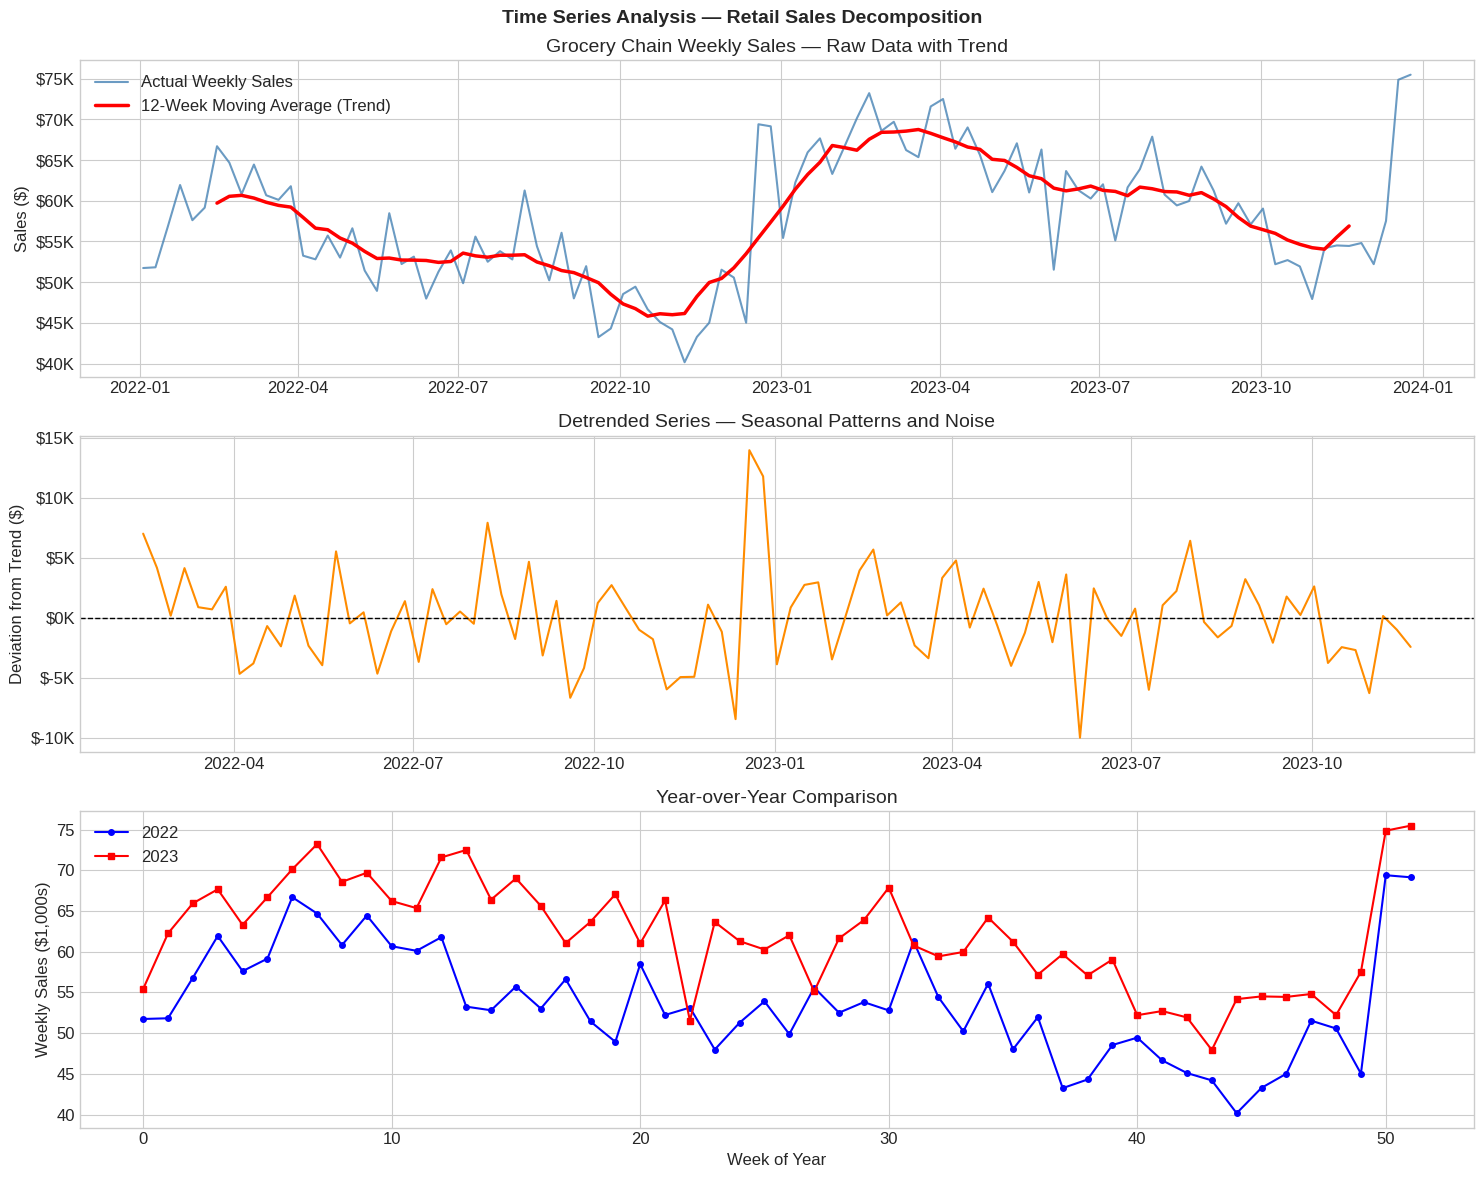

In [22]:
# Decompose the time series

window = 12  # 12-week moving average
moving_avg = ts.rolling(window=window, center=True).mean()
detrended  = ts - moving_avg

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Raw data with trend
ax = axes[0]
ax.plot(ts, color='steelblue', lw=1.5, alpha=0.8, label='Actual Weekly Sales')
ax.plot(moving_avg, color='red', lw=2.5, label=f'{window}-Week Moving Average (Trend)')
ax.set_title('Grocery Chain Weekly Sales — Raw Data with Trend')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()

# Detrended (seasonal + noise)
ax = axes[1]
ax.plot(detrended, color='darkorange', lw=1.5)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_title('Detrended Series — Seasonal Patterns and Noise')
ax.set_ylabel('Deviation from Trend ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Year-over-year comparison
ax = axes[2]
year1 = ts[ts.index.year == 2022].values
year2 = ts[ts.index.year == 2023].values
min_len = min(len(year1), len(year2))
x = range(min_len)
ax.plot(x, year1[:min_len]/1000, 'b-o', ms=4, lw=1.5, label='2022')
ax.plot(x, year2[:min_len]/1000, 'r-s', ms=4, lw=1.5, label='2023')
ax.set_title('Year-over-Year Comparison')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Weekly Sales ($1,000s)')
ax.legend()

plt.suptitle('Time Series Analysis — Retail Sales Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

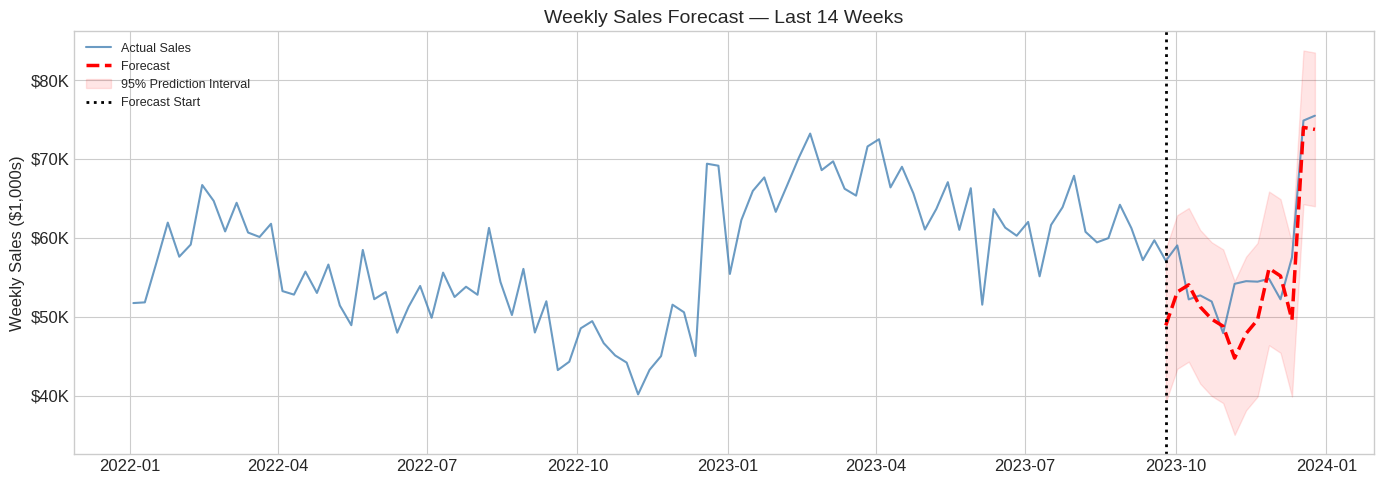

FORECAST ACCURACY
  MAPE (Mean Absolute % Error): 7.2%
  RMSE: $4,968

  MAPE Interpretation:
  On average, our forecasts are off by 7.2%.
  For grocery inventory planning, under 10% is generally acceptable.

  Inventory Planning Implication:
  With a forecast of $73,743 for next week and RMSE of $4,968,
  a safe order quantity that covers 95% of demand scenarios would be:
  $81,940 (forecast + 1.65 standard errors)


In [24]:
# Simple but effective forecasting approach
# We use a combination of: last year's value + trend adjustment
# This is called 'seasonal naive with drift' and is often hard to beat in practice

# Use first 90 weeks as training, forecast the last 14
train_end = 90
train = ts.iloc[:train_end]
test  = ts.iloc[train_end:]

# Seasonal naive with drift: forecast = value from 52 weeks ago + average weekly growth
weekly_trend = (train.iloc[-1] - train.iloc[0]) / len(train)

forecasts = []
for i in range(len(test)):
    seasonal_ref_idx = train_end + i - 52
    if seasonal_ref_idx >= 0:
        base = ts.iloc[seasonal_ref_idx]
    else:
        base = train.mean()
    forecast = base + weekly_trend * 52
    forecasts.append(forecast)

forecasts = np.array(forecasts)
actuals   = test.values

mape = np.mean(np.abs((actuals - forecasts) / actuals)) * 100
rmse_ts = np.sqrt(np.mean((actuals - forecasts)**2))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values/1000, color='steelblue', lw=1.5, label='Actual Sales', alpha=0.8)
ax.plot(test.index, forecasts/1000, color='red', lw=2.5, linestyle='--', label='Forecast')
ax.fill_between(test.index,
                (forecasts - 1.96*rmse_ts)/1000,
                (forecasts + 1.96*rmse_ts)/1000,
                color='red', alpha=0.1, label='95% Prediction Interval')
ax.axvline(ts.index[train_end], color='black', lw=2, linestyle=':', label='Forecast Start')
ax.set_title('Weekly Sales Forecast — Last 14 Weeks')
ax.set_ylabel('Weekly Sales ($1,000s)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.show()

print("FORECAST ACCURACY")
print("=" * 40)
print(f"  MAPE (Mean Absolute % Error): {mape:.1f}%")
print(f"  RMSE: ${rmse_ts:,.0f}")
print()
print("  MAPE Interpretation:")
print(f"  On average, our forecasts are off by {mape:.1f}%.")
print("  For grocery inventory planning, under 10% is generally acceptable.")
print()
print("  Inventory Planning Implication:")
print(f"  With a forecast of ${forecasts[-1]:,.0f} for next week and RMSE of ${rmse_ts:,.0f},")
print(f"  a safe order quantity that covers 95% of demand scenarios would be:")
print(f"  ${forecasts[-1] + 1.65*rmse_ts:,.0f} (forecast + 1.65 standard errors)")

---

# Section 8: Bayesian Thinking in Medicine

## Case Study: Interpreting a Positive Diagnostic Test

### The Business Problem

A patient tests positive for a rare disease. The test is advertised as 99% accurate. The patient is terrified. But what is the actual probability they have the disease?

This is arguably the most practically important application of statistics in everyday life, and most people — including many doctors — get it wrong.

### The Concepts We Will Use

**Bayes' Theorem:** A formula for updating your belief about a hypothesis given new evidence.

P(Disease | Positive Test) = [P(Positive Test | Disease) x P(Disease)] / P(Positive Test)

**Prior Probability:** Your belief about something before seeing new data. P(Disease) = the prevalence of the disease in the population.

**Likelihood:** How probable is the new evidence given our hypothesis? P(Positive Test | Disease) = the sensitivity of the test.

**Posterior Probability:** Your updated belief after seeing new data. P(Disease | Positive Test) = what we want to know.

**Sensitivity:** The probability a test correctly identifies someone who has the disease. (True positive rate)

**Specificity:** The probability a test correctly identifies someone who does not have the disease. (True negative rate)

**The Base Rate Fallacy:** Ignoring the prior probability (how rare is the disease?) when interpreting test results. This is why a 'highly accurate' test for a very rare condition can still be wrong most of the time.

In [ ]:
# Bayes' Theorem applied to medical diagnosis

def bayes_diagnostic(prevalence, sensitivity, specificity, label=''):
    """
    prevalence:  P(Disease)           — how common is the disease?
    sensitivity: P(Positive | Disease) — how well does the test find sick people?
    specificity: P(Negative | Healthy) — how well does the test clear healthy people?
    """
    # P(Positive | Disease)
    p_pos_given_disease = sensitivity

    # P(Positive | No Disease) = 1 - specificity (false positive rate)
    p_pos_given_healthy = 1 - specificity

    # P(Positive) = total probability of a positive result
    p_positive = (p_pos_given_disease * prevalence +
                  p_pos_given_healthy * (1 - prevalence))

    # Bayes' Theorem: P(Disease | Positive)
    p_disease_given_positive = (p_pos_given_disease * prevalence) / p_positive

    return p_disease_given_positive

sensitivity = 0.99  # Test detects 99% of true cases
specificity = 0.99  # Test correctly clears 99% of healthy people

print("MEDICAL DIAGNOSTIC TEST — BAYESIAN ANALYSIS")
print(f"Test Accuracy: Sensitivity={sensitivity:.0%}, Specificity={specificity:.0%}")
print("=" * 70)
print(f"{'Disease':<30} {'Prevalence':>12} {'P(Disease | Positive Test)':>28}")
print("-" * 70)

scenarios = [
    ('Very rare condition',          0.001),
    ('Rare condition',               0.01),
    ('Moderately common condition',  0.05),
    ('Common condition',             0.20),
    ('Very common condition',        0.50),
]

ppv_values = []
for label, prevalence in scenarios:
    ppv = bayes_diagnostic(prevalence, sensitivity, specificity)
    ppv_values.append(ppv)
    print(f"{label:<30} {prevalence:>12.1%} {ppv:>28.1%}")

print()
print("THE SHOCKING RESULT:")
print("A 99% accurate test for a disease affecting 0.1% of the population")
print(f"has a positive predictive value of only {ppv_values[0]:.1%}.")
print()
print("This means: if you test positive, there is only a ~9% chance you actually have the disease.")
print("91% of positive results are FALSE POSITIVES.")
print()
print("Why? Because the disease is so rare that even a very small false positive rate")
print("generates many false alarms relative to the few true cases.")
print()
print("This is exactly why population-wide screening for rare diseases requires careful design.")
print("It is also why a second confirmatory test is standard medical practice.")

In [ ]:
# Visualize the base rate fallacy with a frequency diagram
# (This is the most effective way to explain this concept to non-statisticians)

population = 10000
prevalence = 0.001  # Very rare: 0.1%
sensitivity = 0.99
specificity = 0.99

true_sick    = int(population * prevalence)
true_healthy = population - true_sick

# Of the sick:
true_positives  = int(true_sick * sensitivity)
false_negatives = true_sick - true_positives

# Of the healthy:
false_positives = int(true_healthy * (1 - specificity))
true_negatives  = true_healthy - false_positives

total_positives = true_positives + false_positives
ppv = true_positives / total_positives

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Confusion matrix style breakdown ---
ax = axes[0]
categories = ['True Positives\n(Sick + Positive Test)',
               'False Positives\n(Healthy + Positive Test)',
               'False Negatives\n(Sick + Negative Test)',
               'True Negatives\n(Healthy + Negative Test)']
values = [true_positives, false_positives, false_negatives, true_negatives]
colors = ['tomato', 'orange', 'steelblue', 'mediumseagreen']
bars = ax.barh(categories, values, color=colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11)
ax.set_title(f'Out of {population:,} People Tested\n(Disease Prevalence = {prevalence:.1%})')
ax.set_xlabel('Number of People')

# --- Right: PPV across prevalence levels ---
ax = axes[1]
prevalences = np.linspace(0.001, 0.5, 200)
ppvs = [bayes_diagnostic(p, sensitivity, specificity) for p in prevalences]
ax.plot(prevalences * 100, [p * 100 for p in ppvs], color='steelblue', lw=2.5)
ax.axhline(50, color='gray', linestyle='--', alpha=0.7, label='50% threshold')
ax.axvline(0.1, color='red', linestyle=':', lw=1.5, label='0.1% prevalence (our scenario)')
ax.fill_between(prevalences * 100, [p * 100 for p in ppvs], alpha=0.2, color='steelblue')
ax.set_xlabel('Disease Prevalence (%)')
ax.set_ylabel('Positive Predictive Value — P(Disease | Positive) (%)')
ax.set_title('How Prevalence Determines Whether a Positive Test is Meaningful')
ax.legend()

plt.suptitle('Bayesian Reasoning in Medical Diagnosis — The Base Rate Fallacy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"If you test positive for this disease:")
print(f"  True sick among all positive tests:   {true_positives} out of {total_positives}")
print(f"  Probability you are actually sick:    {ppv:.1%}")
print()
print("After a second independent positive test, what is the probability?")
updated_prevalence = ppv  # First test result becomes the new prior
updated_ppv = bayes_diagnostic(updated_prevalence, sensitivity, specificity)
print(f"  Updated probability (sequential Bayesian update): {updated_ppv:.1%}")
print()
print("This is why confirmatory testing is so powerful.")
print("Each positive result updates the prior and the probability converges rapidly toward certainty.")

---

# Section 9: Capstone — A Full Statistical Investigation

## Case Study: Customer Churn Analysis for a Telecom Company

### The Business Problem

A telecommunications company is losing customers to competitors. Acquiring a new customer costs approximately 5 times more than retaining an existing one. The company has compiled historical data on 1,000 customers — their usage patterns, plan type, tenure, and whether they churned (cancelled their subscription) in the last quarter.

The analytics team has been asked to answer these questions:

1. What is the overall churn rate, and is it statistically different across customer segments?
2. Which features most strongly predict churn?
3. Can we build a model to identify at-risk customers before they leave?
4. Given the cost structure, what is the expected ROI of a targeted retention campaign?

### The Approach

This is a complete end-to-end analysis. We follow the full statistical workflow:
Define -> Explore -> Test -> Model -> Interpret -> Recommend

In [ ]:
# Generate realistic telecom churn dataset

np.random.seed(42)
n_customers = 1000

# Features
tenure_months    = np.random.exponential(24, n_customers).clip(1, 72).round(0)
monthly_charges  = np.random.normal(65, 20, n_customers).clip(20, 120).round(2)
support_calls    = np.random.poisson(1.5, n_customers)
contract_type    = np.random.choice(['Month-to-Month', '1-Year', '2-Year'],
                                     p=[0.55, 0.25, 0.20], size=n_customers)
has_tech_support = np.random.choice([0, 1], p=[0.45, 0.55], size=n_customers)

# Churn probability is a function of these features
def churn_prob(tenure, charge, calls, contract, support):
    log_odds = (
        -0.05 * tenure          # Longer tenure = less likely to churn
        + 0.02 * charge          # Higher charges = more likely to churn
        + 0.35 * calls           # More support calls = more frustrated = more churn
        + (1.5 if contract == 'Month-to-Month' else 0.2 if contract == '1-Year' else -0.8)  # Contract effect
        - 0.8 * support          # Tech support reduces churn
        - 1.5                    # Intercept (baseline log-odds)
    )
    return 1 / (1 + np.exp(-log_odds))

churn_probs = np.array([
    churn_prob(tenure_months[i], monthly_charges[i], support_calls[i],
               contract_type[i], has_tech_support[i])
    for i in range(n_customers)
])

churn = np.random.binomial(1, churn_probs, size=n_customers)

df_churn = pd.DataFrame({
    'customer_id':     range(1, n_customers + 1),
    'tenure_months':   tenure_months,
    'monthly_charges': monthly_charges,
    'support_calls':   support_calls,
    'contract_type':   contract_type,
    'has_tech_support': has_tech_support,
    'churn':           churn
})

print("Telecom Churn Dataset — Overview")
print("-" * 40)
print(f"  Total Customers: {len(df_churn):,}")
print(f"  Churned:         {df_churn['churn'].sum():,} ({df_churn['churn'].mean():.1%})")
print(f"  Retained:        {(df_churn['churn']==0).sum():,} ({1-df_churn['churn'].mean():.1%})")
print()
print(df_churn.groupby('contract_type')['churn'].agg(['sum','mean','count'])
      .rename(columns={'sum':'churned','mean':'churn_rate','count':'total'})
      .assign(churn_rate=lambda x: x['churn_rate'].map('{:.1%}'.format)))

In [ ]:
# Exploratory Analysis — Understand who is churning

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

churned  = df_churn[df_churn['churn'] == 1]
retained = df_churn[df_churn['churn'] == 0]

# Tenure distribution
ax = axes[0, 0]
ax.hist(retained['tenure_months'], bins=25, color='steelblue', alpha=0.65, label='Retained', density=True)
ax.hist(churned['tenure_months'],  bins=25, color='coral',     alpha=0.65, label='Churned',  density=True)
ax.set_title('Tenure Distribution by Churn Status')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Density')
ax.legend()

# Monthly charges
ax = axes[0, 1]
ax.hist(retained['monthly_charges'], bins=25, color='steelblue', alpha=0.65, label='Retained', density=True)
ax.hist(churned['monthly_charges'],  bins=25, color='coral',     alpha=0.65, label='Churned',  density=True)
ax.set_title('Monthly Charges Distribution by Churn Status')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density')
ax.legend()

# Churn rate by contract type
ax = axes[1, 0]
contract_churn = df_churn.groupby('contract_type')['churn'].mean() * 100
colors = ['tomato', 'gold', 'mediumseagreen']
bars = ax.bar(contract_churn.index, contract_churn.values, color=colors, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, max(contract_churn.values) * 1.25)

# Churn rate by support calls
ax = axes[1, 1]
support_churn = df_churn.groupby('support_calls')['churn'].mean() * 100
ax.bar(support_churn.index, support_churn.values, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.set_title('Churn Rate by Number of Support Calls')
ax.set_xlabel('Number of Support Calls (last quarter)')
ax.set_ylabel('Churn Rate (%)')

plt.suptitle('Capstone: Telecom Churn — Exploratory Data Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical Tests — Is the churn rate difference by contract type statistically significant?

from scipy.stats import chi2_contingency

print("CHI-SQUARED TEST: Is churn independent of contract type?")
print("=" * 60)
print("  H0: Churn rate does not depend on contract type")
print("  H1: Churn rate is different across contract types")
print()

contingency = pd.crosstab(df_churn['contract_type'], df_churn['churn'])
contingency.columns = ['Retained', 'Churned']
print("Contingency Table:")
print(contingency)
print()

chi2, p_val, dof, expected = chi2_contingency(contingency)
print(f"  Chi-squared statistic: {chi2:.4f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value: {p_val:.6f}")
print()

if p_val < 0.05:
    print("  REJECT H0: Churn rate is significantly associated with contract type.")
    print("  Month-to-Month customers churn at a dramatically higher rate.")
    print("  Converting customers to annual contracts should be a priority.")

print()
print("t-TEST: Do churned customers have different tenure than retained customers?")
print("=" * 60)
t_stat, p_val_t = ttest_ind(churned['tenure_months'], retained['tenure_months'])
print(f"  Churned mean tenure:  {churned['tenure_months'].mean():.1f} months")
print(f"  Retained mean tenure: {retained['tenure_months'].mean():.1f} months")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_val_t:.6f}")
if p_val_t < 0.05:
    print("  REJECT H0: Churned customers have significantly shorter tenure.")
    print("  Early-tenure customers are at highest risk — this is the critical intervention window.")

In [ ]:
# Build a Logistic Regression model to predict churn probability
# Logistic regression is a linear model for binary outcomes
# Output is a probability between 0 and 1

# Encode categorical variable
df_model = df_churn.copy()
df_model['contract_m2m']  = (df_model['contract_type'] == 'Month-to-Month').astype(int)
df_model['contract_1yr']  = (df_model['contract_type'] == '1-Year').astype(int)

feature_cols = ['tenure_months','monthly_charges','support_calls',
                'has_tech_support','contract_m2m','contract_1yr']

X = df_model[feature_cols]
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_class = (y_pred_proba >= 0.5).astype(int)

print("LOGISTIC REGRESSION — CHURN PREDICTION MODEL")
print("=" * 60)
print()
print("Feature Coefficients (effect on churn probability):")
print("(Positive = increases churn probability, Negative = decreases it)")
print()
for feat, coef in sorted(zip(feature_cols, log_reg.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    direction = "increases" if coef > 0 else "reduces "
    print(f"  {feat:<22}: {coef:>7.4f}  ({direction} churn risk)")

print()
print("Model Performance on Test Set:")
print(classification_report(y_test, y_pred_class, target_names=['Retained','Churned']))

In [ ]:
# Business decision: ROI of a targeted retention campaign

print("RETENTION CAMPAIGN — ROI ANALYSIS")
print("=" * 65)
print()

# Business parameters
total_customers     = 50000     # Actual customer base
monthly_arpu        = 68        # Average revenue per user per month
avg_lifetime_months = 30        # Average months a customer stays
churn_rate_current  = df_churn['churn'].mean()  # Current quarterly churn rate

# Campaign parameters
intervention_cost_per_customer = 25   # Cost to reach and offer a promotion
promotion_value                = 15   # Monthly discount offered for 3 months
campaign_effectiveness         = 0.30 # 30% of at-risk customers respond and stay

# Identify high-risk customers using the model
risk_threshold = 0.60  # Target customers with >60% predicted churn probability
high_risk_test = (y_pred_proba >= risk_threshold).sum()
high_risk_pct  = high_risk_test / len(y_test)
high_risk_n    = int(total_customers * high_risk_pct)

print(f"  Current quarterly churn rate: {churn_rate_current:.1%}")
print(f"  Customers at high risk (>60% churn prob): ~{high_risk_n:,} ({high_risk_pct:.1%} of base)")
print()

# Without campaign: revenue lost to churn
churned_without = high_risk_n * churn_rate_current
revenue_lost    = churned_without * monthly_arpu * avg_lifetime_months

# With campaign: some customers are retained
saved_customers      = high_risk_n * campaign_effectiveness
campaign_cost        = high_risk_n * intervention_cost_per_customer
promotion_cost_total = saved_customers * (promotion_value * 3)
revenue_saved        = saved_customers * monthly_arpu * avg_lifetime_months

net_benefit = revenue_saved - campaign_cost - promotion_cost_total
roi         = (net_benefit / (campaign_cost + promotion_cost_total)) * 100

print(f"  --- Without Campaign ---")
print(f"  Expected churners from high-risk group: {churned_without:,.0f}")
print(f"  Revenue lost (lifetime value): ${revenue_lost:,.0f}")
print()
print(f"  --- With Targeted Retention Campaign ---")
print(f"  Customers contacted: {high_risk_n:,}")
print(f"  Expected customers saved: {saved_customers:,.0f}")
print(f"  Campaign outreach cost: ${campaign_cost:,.0f}")
print(f"  Promotion discount cost: ${promotion_cost_total:,.0f}")
print(f"  Revenue saved (lifetime value): ${revenue_saved:,.0f}")
print(f"  Net Benefit: ${net_benefit:,.0f}")
print(f"  ROI: {roi:.0f}%")
print()
print(f"  CONCLUSION: For every $1 spent on the targeted retention campaign,")
print(f"  the company expects a return of ${1 + roi/100:.2f}.")
print(f"  The statistical model makes this targeting possible.")
print(f"  Without it, the company would waste budget on low-risk customers")
print(f"  or miss the high-risk ones entirely.")

In [ ]:
# Final visualization: Churn probability distribution and risk segmentation

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Predicted churn probability distribution
ax = axes[0]
colors_pred = ['steelblue' if p < 0.60 else 'tomato' for p in y_pred_proba]
ax.hist(y_pred_proba[y_pred_proba <  0.60], bins=25, color='steelblue', alpha=0.75, label='Low Risk (<60%)',  density=True)
ax.hist(y_pred_proba[y_pred_proba >= 0.60], bins=25, color='tomato',    alpha=0.75, label='High Risk (>=60%)', density=True)
ax.axvline(0.60, color='black', lw=2, linestyle='--', label='Campaign threshold')
ax.set_title('Distribution of Predicted Churn Probabilities')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.legend()

# ROC Curve analogy: show the tradeoff between precision and recall
thresholds = np.linspace(0.1, 0.9, 50)
precisions, recalls = [], []
for thresh in thresholds:
    preds = (y_pred_proba >= thresh).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisions.append(prec)
    recalls.append(rec)

ax = axes[1]
ax.plot(recalls, precisions, color='steelblue', lw=2.5)
ax.scatter([recalls[thresholds.tolist().index(min(thresholds, key=lambda t: abs(t-0.60)))]],
           [precisions[thresholds.tolist().index(min(thresholds, key=lambda t: abs(t-0.60)))]],
           color='red', s=100, zorder=5, label='60% threshold (our choice)')
ax.set_title('Precision-Recall Tradeoff\n(Higher precision = fewer false alarms)')
ax.set_xlabel('Recall (% of actual churners we catch)')
ax.set_ylabel('Precision (% of flagged customers who actually churn)')
ax.legend()

plt.suptitle('Capstone Final: Churn Model Risk Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Conclusion: What You Now Know and How to Use It

## The Statistical Toolkit You Have Built

Throughout this notebook, we have applied a core set of statistical tools across five different industries. Here is a clean reference for when to use each one:

| Tool | When to Use | Industry Examples |
|---|---|---|
| Descriptive Statistics | Any time you first encounter a dataset | Healthcare, Finance, HR |
| Normal Distribution | Modeling quantities that arise from many small effects | Manufacturing, Finance |
| Poisson Distribution | Counting events over time or space | Insurance, Operations, Web Traffic |
| t-Test | Comparing means between two groups | Manufacturing, Clinical Trials, Marketing |
| Chi-Squared Test | Comparing proportions across categories | A/B Testing, Churn Analysis |
| Linear Regression | Predicting a continuous numeric outcome | Real Estate, Sales Forecasting |
| Logistic Regression | Predicting a binary (yes/no) outcome | Churn, Credit Risk, Medical Diagnosis |
| A/B Test | Evaluating the effect of a controlled change | Product, Marketing, UX |
| Time Series | Analyzing data indexed by time | Retail, Finance, Operations |
| Bayes' Theorem | Updating beliefs with evidence sequentially | Medicine, Spam Filtering, Search |

## The Most Important Lessons

**The average is never the whole story.** Always look at the full distribution — variance, skewness, outliers. A single number compresses information in ways that lead to bad decisions.

**Statistical significance is not the same as practical significance.** A result can be real (p < 0.05) and completely unimportant (Cohen's d = 0.05). Always report effect sizes alongside p-values.

**Correlation is not causation.** Two variables moving together does not mean one causes the other. Before claiming causality, you need either a controlled experiment (A/B test, randomized trial) or a careful causal analysis.

**The base rate matters.** Ignoring how common or rare something is leads to wildly wrong conclusions. Bayes' theorem is the antidote to this error.

**Residuals tell you if you can trust your model.** Always plot residuals. Patterns in residuals mean your model is missing something important.

**Your sample size must be planned before the experiment.** Never run a test until you see something you like, then stop. Pre-register your sample size and stop when you reach it.

## How to Approach Any New Data Problem

When you are handed a dataset at a new job, follow this order:

1. Understand what each column means and how the data was collected
2. Check data quality: missing values, duplicates, obvious errors
3. Compute descriptive statistics: shape, center, spread for every variable
4. Visualize distributions and relationships
5. Formulate a specific, testable question
6. Choose the appropriate statistical method based on: the type of outcome variable (continuous vs binary), the type of comparison (two groups vs multiple), and whether assumptions are met
7. Run the analysis, check assumptions, interpret results in context
8. Translate the result into a concrete recommendation

That last step is what separates analysts from advisors. Numbers do not make decisions. People do. Your job is to help those people understand what the data says — clearly, honestly, and in the language of the problem they are trying to solve.

In [25]:
# Quick Reference: Statistical Test Selection Guide
# Run this cell any time to get a reminder of which test to use

def recommend_test(outcome_type, n_groups, paired=False, large_sample=True):
    """
    A simple decision function to help choose the right statistical test.

    outcome_type: 'continuous' or 'categorical'
    n_groups: 1, 2, or 3+ (number of groups being compared)
    paired: True if the same subjects appear in both groups
    large_sample: True if n > 30 per group
    """
    print(f"Input: outcome='{outcome_type}', groups={n_groups}, paired={paired}, large_sample={large_sample}")
    print("Recommended test:")

    if outcome_type == 'continuous':
        if n_groups == 1:
            print("  One-Sample t-test: Is the mean different from a known value?")
        elif n_groups == 2:
            if paired:
                print("  Paired t-test: Compare the same subjects under two conditions (before/after)")
            else:
                if large_sample:
                    print("  Independent Samples t-test (or z-test for very large n)")
                else:
                    print("  Independent Samples t-test. Check normality with Shapiro-Wilk first.")
                    print("  If non-normal: Mann-Whitney U test (non-parametric alternative)")
        elif n_groups >= 3:
            print("  One-Way ANOVA: Compare means across 3+ groups")
            print("  Follow with Tukey's HSD post-hoc test to find which pairs differ")

    elif outcome_type == 'categorical':
        if n_groups == 2:
            print("  Two-Proportion z-test or Chi-Squared test")
            print("  Use when comparing conversion rates, churn rates, defect rates, etc.")
        elif n_groups >= 3:
            print("  Chi-Squared Test of Independence")
            print("  Use with a contingency table of counts")

    print()

print("=" * 60)
print("STATISTICAL TEST SELECTION GUIDE")
print("=" * 60)
print()

recommend_test('continuous', 2, paired=False, large_sample=True)
recommend_test('continuous', 2, paired=True)
recommend_test('continuous', 3)
recommend_test('categorical', 2)
recommend_test('categorical', 4)

print("=" * 60)
print("When modeling (not testing):")
print("  Continuous outcome   -> Linear Regression")
print("  Binary outcome       -> Logistic Regression")
print("  Multi-class outcome  -> Multinomial Logistic Regression or Random Forest")
print("  Time-ordered data    -> ARIMA, Exponential Smoothing, or Prophet")
print("  Updating beliefs     -> Bayes' Theorem / Bayesian modeling")
print("=" * 60)

STATISTICAL TEST SELECTION GUIDE

Input: outcome='continuous', groups=2, paired=False, large_sample=True
Recommended test:
  Independent Samples t-test (or z-test for very large n)

Input: outcome='continuous', groups=2, paired=True, large_sample=True
Recommended test:
  Paired t-test: Compare the same subjects under two conditions (before/after)

Input: outcome='continuous', groups=3, paired=False, large_sample=True
Recommended test:
  One-Way ANOVA: Compare means across 3+ groups
  Follow with Tukey's HSD post-hoc test to find which pairs differ

Input: outcome='categorical', groups=2, paired=False, large_sample=True
Recommended test:
  Two-Proportion z-test or Chi-Squared test
  Use when comparing conversion rates, churn rates, defect rates, etc.

Input: outcome='categorical', groups=4, paired=False, large_sample=True
Recommended test:
  Chi-Squared Test of Independence
  Use with a contingency table of counts

When modeling (not testing):
  Continuous outcome   -> Linear Regression

---

## Further Reading and Next Steps

If you want to deepen your understanding of the topics covered in this notebook, these are the most useful directions to pursue:

**On statistical foundations:** "Statistics" by Freedman, Pisani, and Purves remains the best conceptual statistics textbook ever written. It builds intuition first, formulas second.

**On experimental design:** "Causal Inference: The Mixtape" by Scott Cunningham covers the methods needed to move from correlation to causation — a critical skill for anyone doing applied work.

**On Bayesian statistics:** "Thinking, Fast and Slow" by Daniel Kahneman is not a statistics book, but it explains in accessible terms why humans are terrible at probabilistic reasoning and why Bayesian thinking corrects for our natural errors.

**On time series:** "Forecasting: Principles and Practice" by Hyndman and Athanasopoulos is available free online and is the most practical resource on demand forecasting.

**On machine learning in practice:** "The Elements of Statistical Learning" by Hastie, Tibshirani, and Friedman bridges classical statistics and modern machine learning.

---

The best way to internalize everything in this notebook is to take a dataset from your own life or industry, and walk through the full workflow from scratch. Find a question that matters, collect or download data, and use these tools to try to answer it. That single exercise will teach you more than reviewing any amount of theory.